In [1]:
# ── Cell 0.1 — Path setup ─────────────────────────────────────────────────
#
# We run the notebook from the notebooks/ subfolder.
# Adding '..' to sys.path lets Python find:
#   - vqshape/      (the model package)
#   - data_provider/ (imported internally by vqshape)
#   - src/           (our preprocessing and utils)

import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')          # set working directory to project root

print("Working directory:", os.getcwd())
# Expected: D:\Documents\Intership TSC\Projects\health-interpretable-ts

Working directory: d:\Documents\Intership TSC\Projects\health-interpretable-ts


In [2]:
# ── Cell 0.2 — All imports ────────────────────────────────────────────────
#
# Import everything upfront so missing packages are caught immediately
# rather than halfway through a long training run.

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from einops import rearrange

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("All imports OK")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All imports OK
PyTorch version : 2.4.0+cu121
CUDA available  : True


In [3]:
# ── Cell 0.3 — Global constants ───────────────────────────────────────────
#
# All magic numbers in one place.
# If you change checkpoint, update CODEBOOK_SIZE to match.
#   uea_dim256_codebook512 → CODEBOOK_SIZE = 512
#   uea_dim512_codebook64  → CODEBOOK_SIZE = 64

DEVICE         = 'cuda:0' if torch.cuda.is_available() else 'cpu'
CKPT_PATH      = 'checkpoints/uea_dim256_codebook512/VQShape.ckpt'
DATA_DIR       = 'data/raw/ptb-xl'
OUTPUTS_DIR    = 'outputs'

NORMALIZE_LEN  = 512      # VQShape always expects 512 timesteps
N_PATCHES      = 64       # patches per signal (--num_patch 64)
DIM_CODE       = 8        # dim_code per token (from actual output shape)
CODEBOOK_SIZE  = 512      # codebook entries in uea_dim256_codebook512
N_CHANNELS     = 12       # PTB-XL has 12 ECG leads
N_CLASSES      = 5        # NORM, MI, STTC, CD, HYP
CLASS_NAMES    = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
CLASS_COLORS   = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

os.makedirs(OUTPUTS_DIR, exist_ok=True)
print(f"Device          : {DEVICE}")
print(f"Codebook size   : {CODEBOOK_SIZE}")
print(f"Checkpoint      : {CKPT_PATH}")

Device          : cuda:0
Codebook size   : 512
Checkpoint      : checkpoints/uea_dim256_codebook512/VQShape.ckpt


In [4]:
# verify dataset 
# ── Cell 1.1 — Confirm PTB-XL path ───────────────────────────────────────

# No download needed — you already have the data.
# The folder name is the full PhysioNet versioned name.
# We set DATA_DIR once here and use it everywhere below.

import os

DATA_DIR  = 'data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'
ptbxl_csv = os.path.join(DATA_DIR, 'ptbxl_database.csv')

# Verify all required files and folders exist
required = {
    'Main CSV'       : ptbxl_csv,
    'SCP statements' : os.path.join(DATA_DIR, 'scp_statements.csv'),
    'records100/'    : os.path.join(DATA_DIR, 'records100'),
    'records500/'    : os.path.join(DATA_DIR, 'records500'),
}

all_ok = True
for label, path in required.items():
    exists = os.path.exists(path)
    print(f"  {'✓' if exists else '✗ MISSING'}  {label:20s}  {path}")
    if not exists:
        all_ok = False

print()
print("✓ Ready to proceed." if all_ok else "✗ Fix missing paths before continuing.")


  ✓  Main CSV              data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv
  ✓  SCP statements        data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\scp_statements.csv
  ✓  records100/           data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\records100
  ✓  records500/           data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\records500

✓ Ready to proceed.


In [5]:
# ── Cell 1.2 — Load metadata ──────────────────────────────────────────────
#
# ptbxl_database.csv contains one row per recording with:
#   ecg_id, patient_id, age, sex, strat_fold, filename_lr, filename_hr,
#   scp_codes (dict mapping diagnostic code → confidence 0-100)
#
# scp_codes looks like: {'NORM': 100.0}  or  {'IMI': 80.0, 'LVH': 20.0}
# We parse it from string to dict with ast.literal_eval.

import ast

df = pd.read_csv(ptbxl_csv, index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

print(f"Total recordings : {len(df)}")
print(f"Unique patients  : {df.patient_id.nunique()}")
print(f"Age range        : {df.age.min():.0f} – {df.age.max():.0f} years")
print(f"\nFirst row preview:")
df.head(2)

Total recordings : 21799
Unique patients  : 18869
Age range        : 2 – 300 years

First row preview:


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


In [6]:
# ── Cell 1.3 — Assign superclass labels ──────────────────────────────────
#
# Each recording has one or more diagnostic codes in scp_codes.
# scp_statements.csv maps each code to a diagnostic superclass:
#   NORM, MI (Myocardial Infarction), STTC (ST/T-change),
#   CD (Conduction Disturbance), HYP (Hypertrophy)
#
# Strategy: for each recording, pick the superclass with
#           the highest confidence score. NORM if nothing matches.

SUPERCLASS_MAP = {'NORM': 0, 'MI': 1, 'STTC': 2, 'CD': 3, 'HYP': 4}

scp_df = pd.read_csv(os.path.join(DATA_DIR, 'scp_statements.csv'), index_col=0)
scp_df = scp_df[scp_df.diagnostic == 1]    # keep only diagnostic codes

def assign_label(scp_dict):
    best, best_conf = 'NORM', 0.0
    for code, conf in scp_dict.items():
        if code in scp_df.index:
            sc = scp_df.loc[code, 'diagnostic_class']
            if sc in SUPERCLASS_MAP and conf > best_conf:
                best, best_conf = sc, conf
    return SUPERCLASS_MAP[best]

labels = np.array([assign_label(d) for d in df.scp_codes], dtype=np.int64)

print("Label distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (labels == i).sum()
    bar = '█' * (count // 200)
    print(f"  {name:4s} [{i}]  {count:5d}  {bar}")

Label distribution:
  NORM [0]   9670  ████████████████████████████████████████████████
  MI   [1]   4187  ████████████████████
  STTC [2]   3332  ████████████████
  CD   [3]   3322  ████████████████
  HYP  [4]   1288  ██████


In [7]:
# ── Cell 1.4 — Load raw signals ───────────────────────────────────────────
#
# wfdb.rdrecord() takes a path WITHOUT the .hea/.dat extension.
# df.filename_lr contains relative paths like:
#   'records100/00000/00001_lr'
#
# So the full path we pass is:
#   DATA_DIR + '/' + row.filename_lr
#   → 'data/ptb-xl-.../records100/00000/00001_lr'
#
# wfdb finds 00001_lr.hea and 00001_lr.dat automatically.
#
# Verify one record first before loading all 21k:

import wfdb

test_path   = os.path.join(DATA_DIR, df.iloc[0].filename_lr)
test_record = wfdb.rdrecord(test_path)
print(f"Single record test:")
print(f"  path          : {test_path}")
print(f"  p_signal shape: {test_record.p_signal.shape}")
print(f"  fs            : {test_record.fs} Hz")
print(f"  sig_name      : {test_record.sig_name}")
# Expected: shape=(1000, 12), fs=100, sig_name=['I','II',...,'V6']

Single record test:
  path          : data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\records100/00000/00001_lr
  p_signal shape: (1000, 12)
  fs            : 100 Hz
  sig_name      : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [8]:
# Now load all signals — takes ~3-5 min
from tqdm import tqdm

signals = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Loading ECGs'):
    path   = os.path.join(DATA_DIR, row.filename_lr)
    record = wfdb.rdrecord(path)
    signals.append(record.p_signal.astype(np.float32))

signals = np.array(signals)   # (21837, 1000, 12)

print(f"\nSignals shape : {signals.shape}")
print(f"dtype         : {signals.dtype}")
print(f"Memory        : {signals.nbytes / 1e9:.2f} GB")

Loading ECGs: 100%|██████████| 21799/21799 [22:16<00:00, 16.31it/s]  



Signals shape : (21799, 1000, 12)
dtype         : float32
Memory        : 1.05 GB


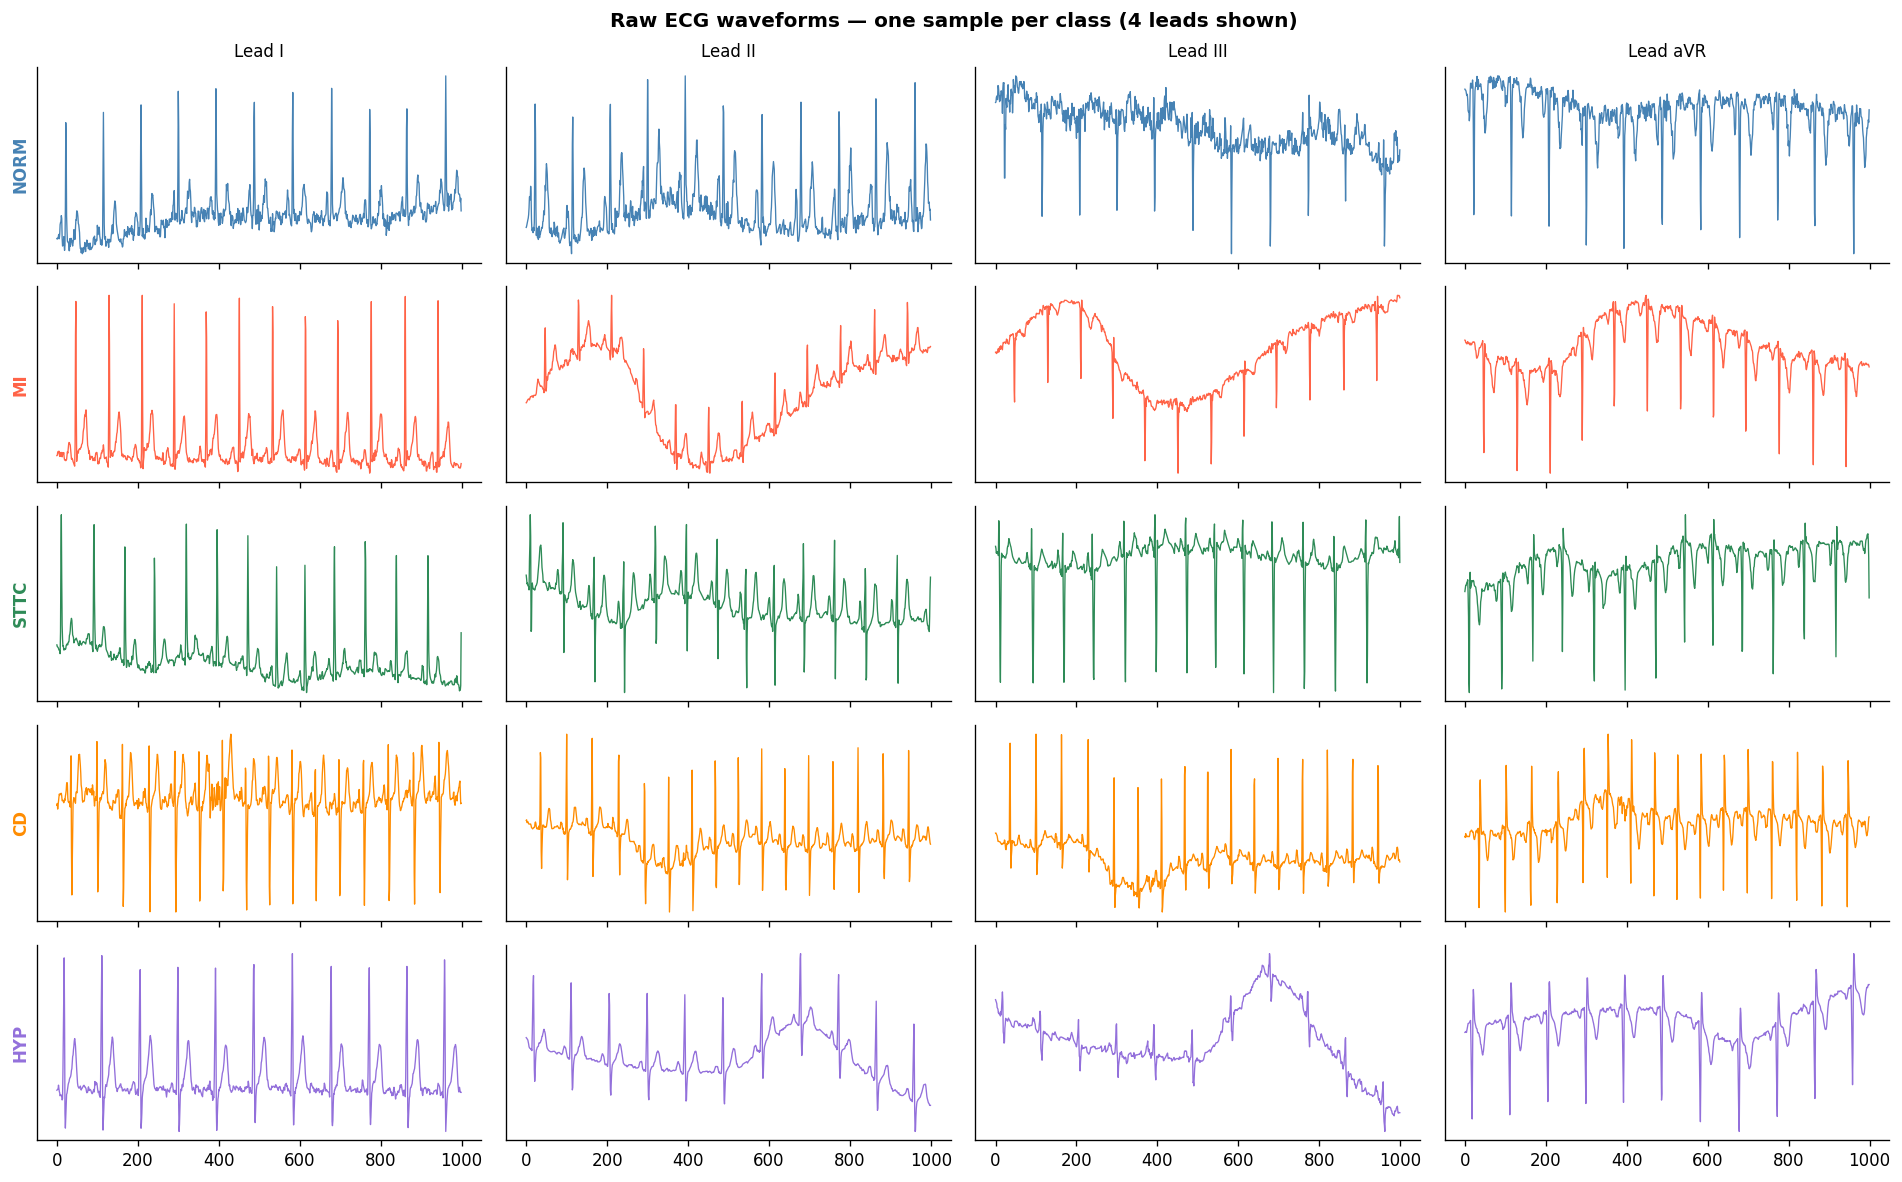

In [9]:
# ── Cell 1.5 — Visualize one ECG per class ───────────────────────────────
import matplotlib.pyplot as plt

lead_names = ['I', 'II', 'III', 'aVR']

fig, axes = plt.subplots(N_CLASSES, 4, figsize=(16, 10), sharex=True)

for c in range(N_CLASSES):
    idx = np.where(labels == c)[0][0]
    for l, ax in enumerate(axes[c]):
        ax.plot(signals[idx, :, l], linewidth=0.8, color=CLASS_COLORS[c])
        if c == 0:
            ax.set_title(f'Lead {lead_names[l]}', fontsize=10)
        if l == 0:
            ax.set_ylabel(CLASS_NAMES[c], fontsize=10,
                          color=CLASS_COLORS[c], fontweight='bold')
        ax.set_yticks([])

fig.suptitle('Raw ECG waveforms — one sample per class (4 leads shown)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_raw_ecg_per_class.png', bbox_inches='tight')
plt.show()

In [10]:
# ── Cell 2.1 — Z-score normalization ─────────────────────────────────────
#
# Why normalize? Raw ECG amplitude varies across patients and leads
# (mV range differs by lead). Z-score normalization makes each channel
# zero-mean, unit-variance across the whole dataset.
#
# We normalize globally (across all N samples) per channel.
# Shape in:  (N, T, C)  →  reshape to (N*T, C)  →  normalize  →  reshape back
# This is the same strategy VQShape uses internally.

from sklearn.preprocessing import StandardScaler

N, T, C = signals.shape
flat        = signals.reshape(-1, C)              # (N*T, C)
flat_normed = StandardScaler().fit_transform(flat)
signals_norm = flat_normed.reshape(N, T, C).astype(np.float32)

print(f"Before norm — mean: {signals.mean():.4f},  std: {signals.std():.4f}")
print(f"After  norm — mean: {signals_norm.mean():.6f}, std: {signals_norm.std():.6f}")
# Expected: after norm mean ≈ 0.0, std ≈ 1.0

Before norm — mean: -0.0008,  std: 0.2354
After  norm — mean: 0.000000, std: 1.000000


In [11]:
# ── Cell 2.2 — Train / val / test split ──────────────────────────────────
#
# PTB-XL provides an official stratified 10-fold column (strat_fold).
# Standard convention (used in the original PTB-XL paper):
#   Folds 1-8 → train   (~17 400 samples)
#   Fold  9   → val     (~ 2 200 samples)
#   Fold  10  → test    (~ 2 200 samples)
#
# This split is patient-stratified — a patient's recordings only appear
# in ONE fold, preventing data leakage.

folds = df.strat_fold.values
idx   = np.arange(len(df))

tr_idx  = idx[folds <= 8]
val_idx = idx[folds == 9]
te_idx  = idx[folds == 10]

X_tr,  y_tr  = signals_norm[tr_idx],  labels[tr_idx]
X_val, y_val = signals_norm[val_idx], labels[val_idx]
X_te,  y_te  = signals_norm[te_idx],  labels[te_idx]

print(f"Train : {X_tr.shape}  — {len(y_tr)} samples")
print(f"Val   : {X_val.shape}  — {len(y_val)} samples")
print(f"Test  : {X_te.shape}  — {len(y_te)} samples")

Train : (17418, 1000, 12)  — 17418 samples
Val   : (2183, 1000, 12)  — 2183 samples
Test  : (2198, 1000, 12)  — 2198 samples


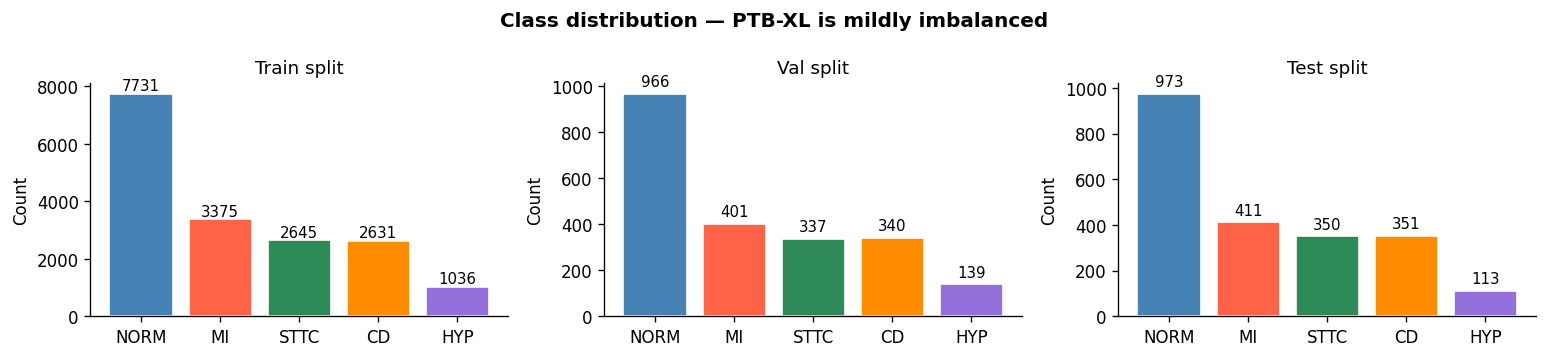

In [12]:
# ── Cell 2.3 — Class balance check ───────────────────────────────────────
#
# PTB-XL is mildly imbalanced (NORM is the largest class).
# We visualize this so we can interpret accuracy numbers correctly later.
# A model predicting NORM for everything would get ~44% accuracy —
# always compare against this baseline.

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (split_y, name) in zip(axes, [(y_tr, 'Train'), (y_val, 'Val'), (y_te, 'Test')]):
    counts = [( labels == c ).sum() for c in range(N_CLASSES)]
    # recalculate for current split
    counts = [(split_y == c).sum() for c in range(N_CLASSES)]
    bars = ax.bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor='white')
    ax.set_title(f'{name} split', fontsize=11)
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20, str(cnt),
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Class distribution — PTB-XL is mildly imbalanced',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/02_class_distribution.png', bbox_inches='tight')
plt.show()

In [13]:
# ── Cell 3.1 — Load VQShape checkpoint ───────────────────────────────────
#
# VQShape is a PyTorch Lightning module (LitVQShape).
# We load the full Lightning checkpoint, then extract the inner model.
#
# Why unwrap? LitVQShape wraps the model with training logic
# (optimizers, schedulers). For inference we only need the model itself.
#
# Important: pass device as a string argument, not as a map_location kwarg.
# This is specific to how LitVQShape.load_from_checkpoint is implemented.

from vqshape.pretrain import LitVQShape

lit_model  = LitVQShape.load_from_checkpoint(CKPT_PATH, DEVICE)
vqs_model  = lit_model.model
vqs_model.eval()
vqs_model.to(DEVICE)

n_params = sum(p.numel() for p in vqs_model.parameters())
print(f"VQShape loaded. Parameters: {n_params:,}")
print(f"Device: {next(vqs_model.parameters()).device}")

VQShape loaded. Parameters: 9,478,997
Device: cuda:0


In [14]:
# # ── Cell 3.2 — Decode the codebook into shape waveforms ──────────────────
# #
# # The codebook is a lookup table of K learned vectors (K = CODEBOOK_SIZE).
# # Each vector lives in the latent space. When we pass it through the
# # decoder, we get back a short time-domain waveform — a "shape primitive".
# #
# # These shapes are what make VQShape interpretable:
# #   Instead of saying "latent vector #42", we say "shape #42 looks like
# #   a sharp upward spike followed by a slow decay" — clinically meaningful.
# #
# # vqs_model.quantizer.embedding.weight : (K, D_hidden)
# # After decode                         : (K, patch_length)
# #   patch_length = NORMALIZE_LEN / N_PATCHES = 512 / 64 = 8

# with torch.no_grad():
#     codebook_vectors = vqs_model.quantizer.embedding.weight  # (512, D)
#     shapes = vqs_model(codebook_vectors, mode='decode')       # (512, 8)
#     shapes = shapes.cpu().numpy()

# print(f"Codebook shape  : {shapes.shape}")
# print(f"  → {shapes.shape[0]} learned shape primitives")
# print(f"  → each is {shapes.shape[1]} timesteps long (patch length)")
# # Expected: (512, 8)

In [15]:
# ── Cell 3.2 — Decode codebook shapes ────────────────────────────────────
#
# The VQShape codebook stores K latent vectors (dim_code).
# We decode each vector into a 1D shape using the shape decoder,
# giving us the learned shape primitives for visualization below.

with torch.no_grad():
    if hasattr(vqs_model.codebook, 'embedding'):
        codebook = vqs_model.codebook.embedding.weight
    elif hasattr(vqs_model.codebook, 'codebook'):
        codebook = vqs_model.codebook.codebook
    elif hasattr(vqs_model.codebook, 'embeddings'):
        codebook = vqs_model.codebook.embeddings
    else:
        raise AttributeError("Couldn't find codebook weights on vqs_model.codebook")

    codebook = codebook.to(DEVICE)
    z = codebook.unsqueeze(0)  # (1, K, dim_code)
    shapes_norm, _, _ = vqs_model.shape_decoder(z)
    shapes = shapes_norm.squeeze(0).detach().cpu().numpy()

print(f"Decoded shapes: {shapes.shape}")

Decoded shapes: (512, 128)


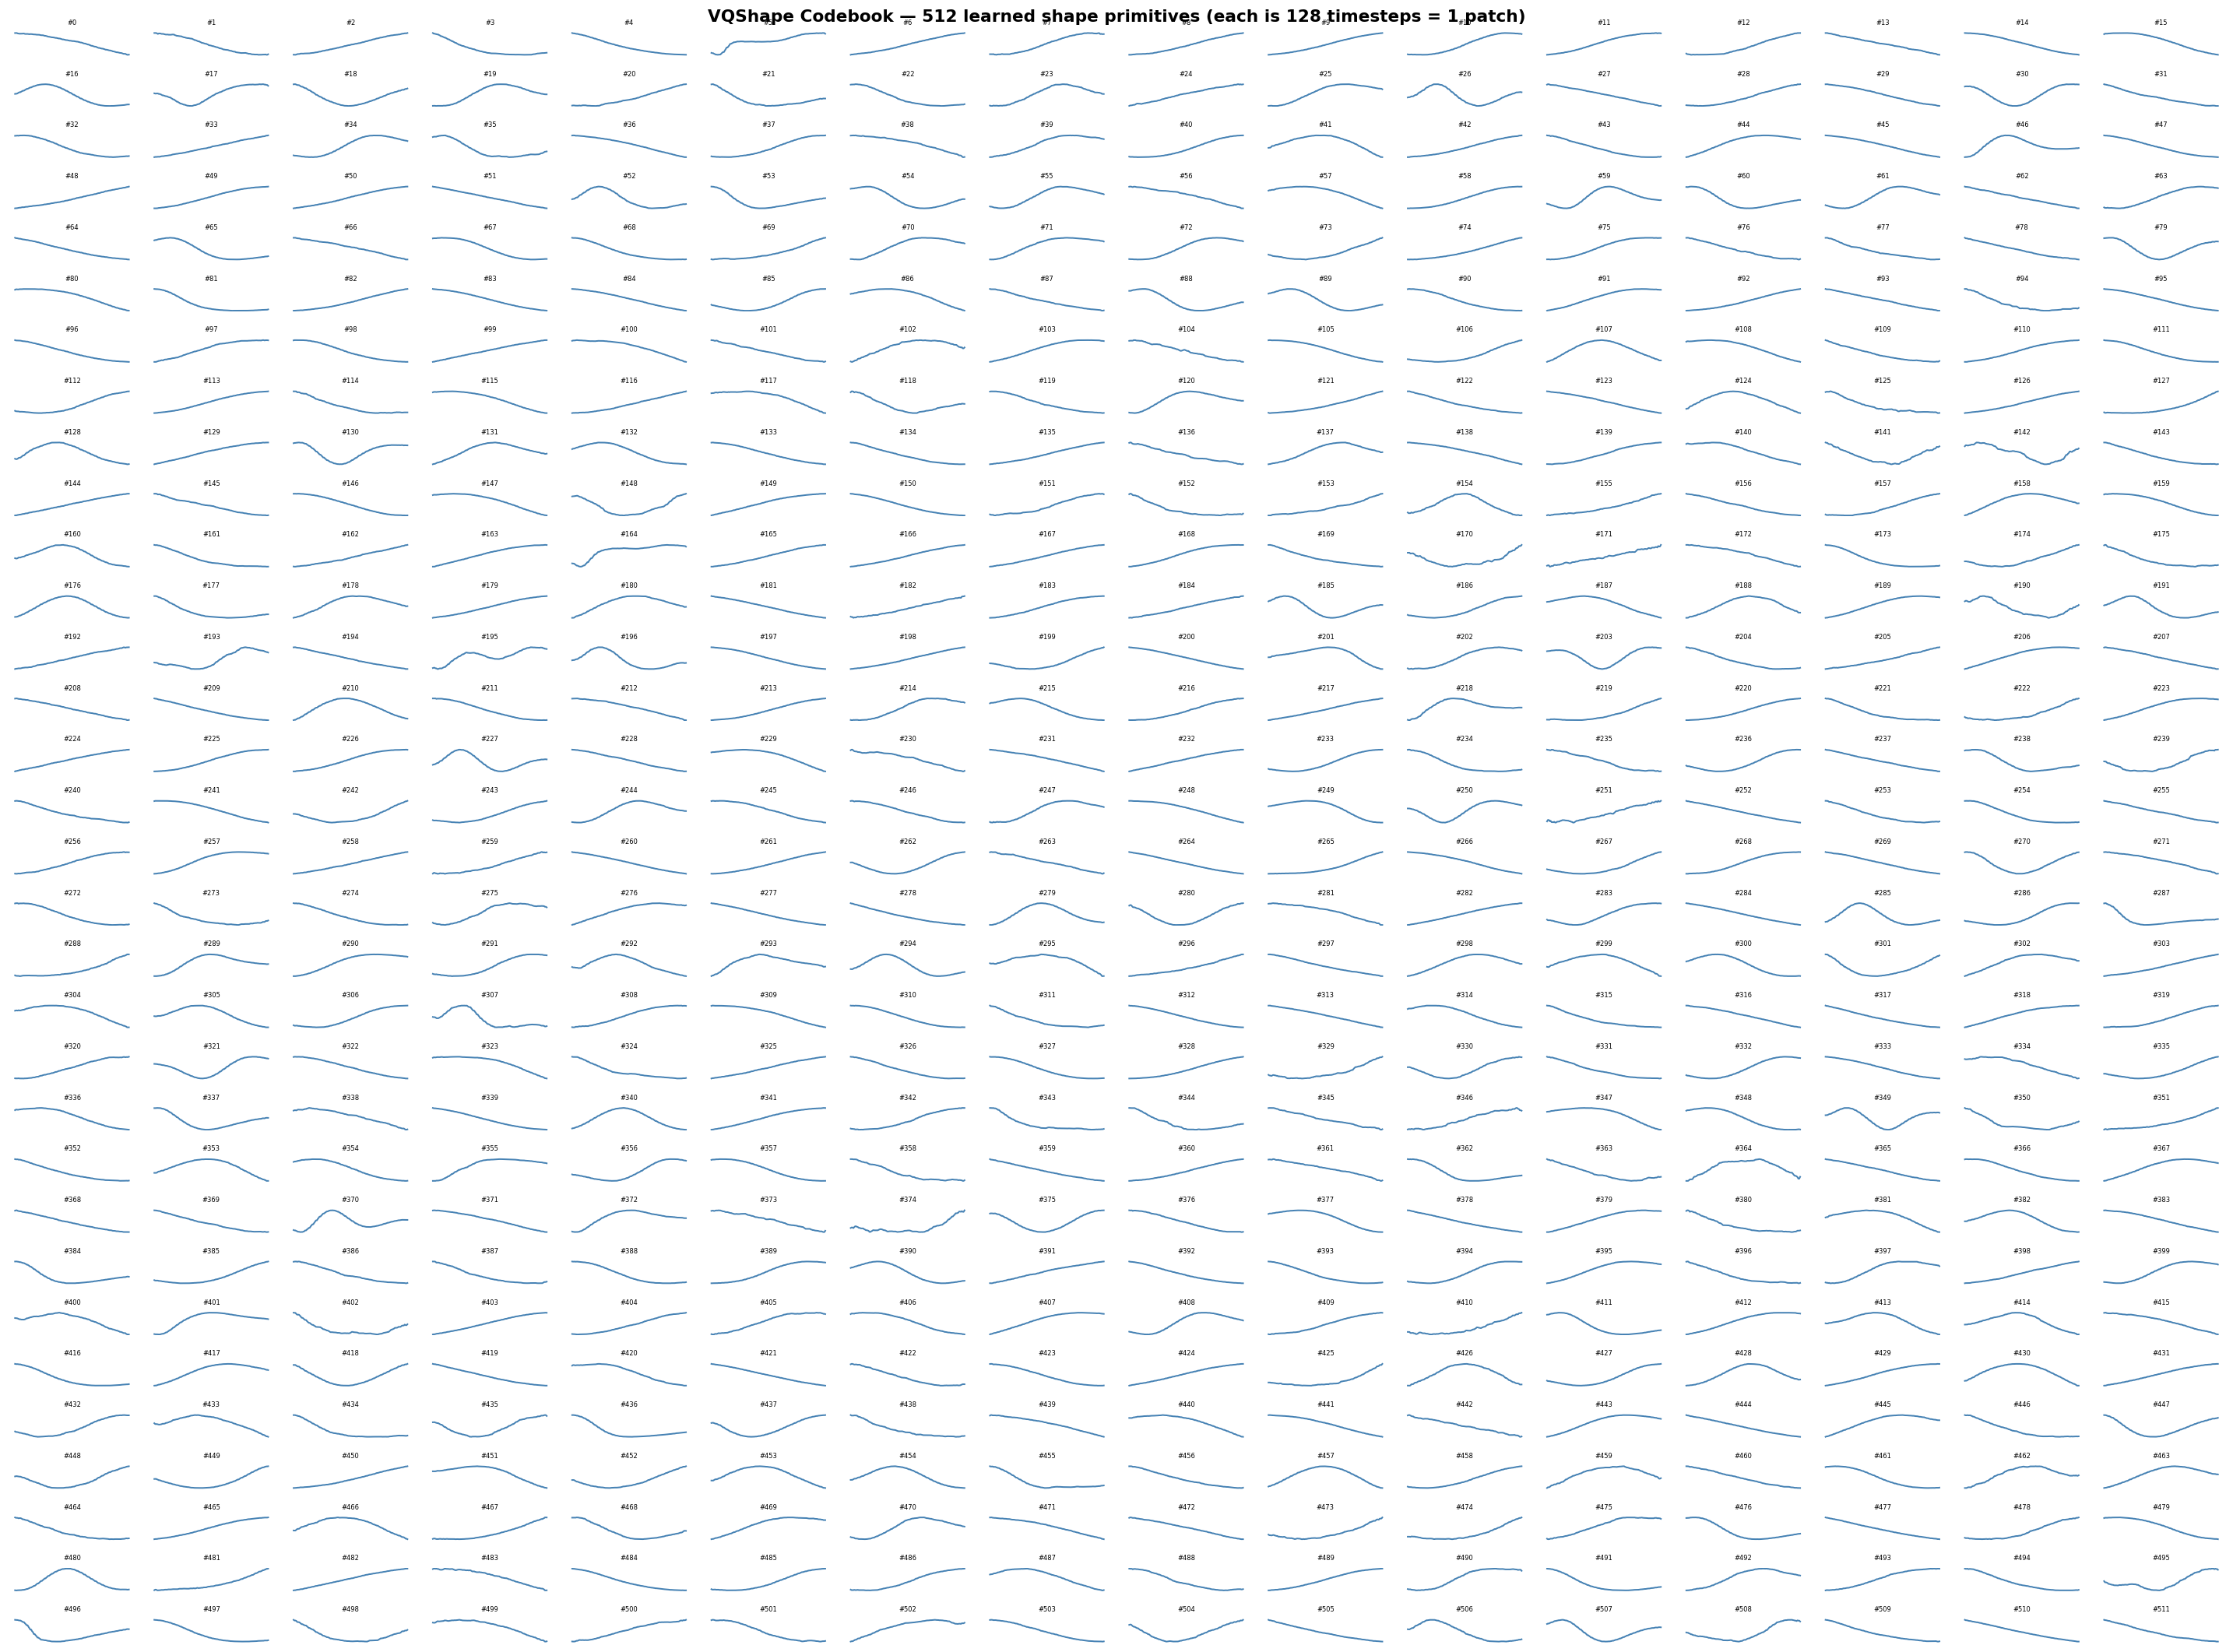

Saved → outputs/03_full_codebook.png


In [16]:
# ── Cell 3.3 — Visualize the full codebook ───────────────────────────────
#
# Each subplot = one shape primitive the model learned from 30+ TS datasets.
# Look for recognizable motifs:
#   - Smooth bumps     → likely maps to P-waves or T-waves in ECG
#   - Sharp spikes     → likely maps to QRS complexes
#   - Flat plateaus    → likely maps to isoelectric segments
#   - Oscillations     → likely maps to atrial fibrillation patterns
#
# This figure = the "shape dictionary". Every ECG will be described
# as a sequence of these 512 primitives.

K, L = shapes.shape
n_cols = 16
n_rows = K // n_cols    # = 32 rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 18))
axes = axes.flatten()

for i in range(K):
    axes[i].plot(shapes[i], linewidth=1.2, color='steelblue')
    axes[i].set_title(f'#{i}', fontsize=5)
    axes[i].axis('off')

plt.suptitle(
    f'VQShape Codebook — {K} learned shape primitives '
    f'(each is {L} timesteps = 1 patch)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/03_full_codebook.png', bbox_inches='tight', dpi=100)
plt.show()
print("Saved → outputs/03_full_codebook.png")

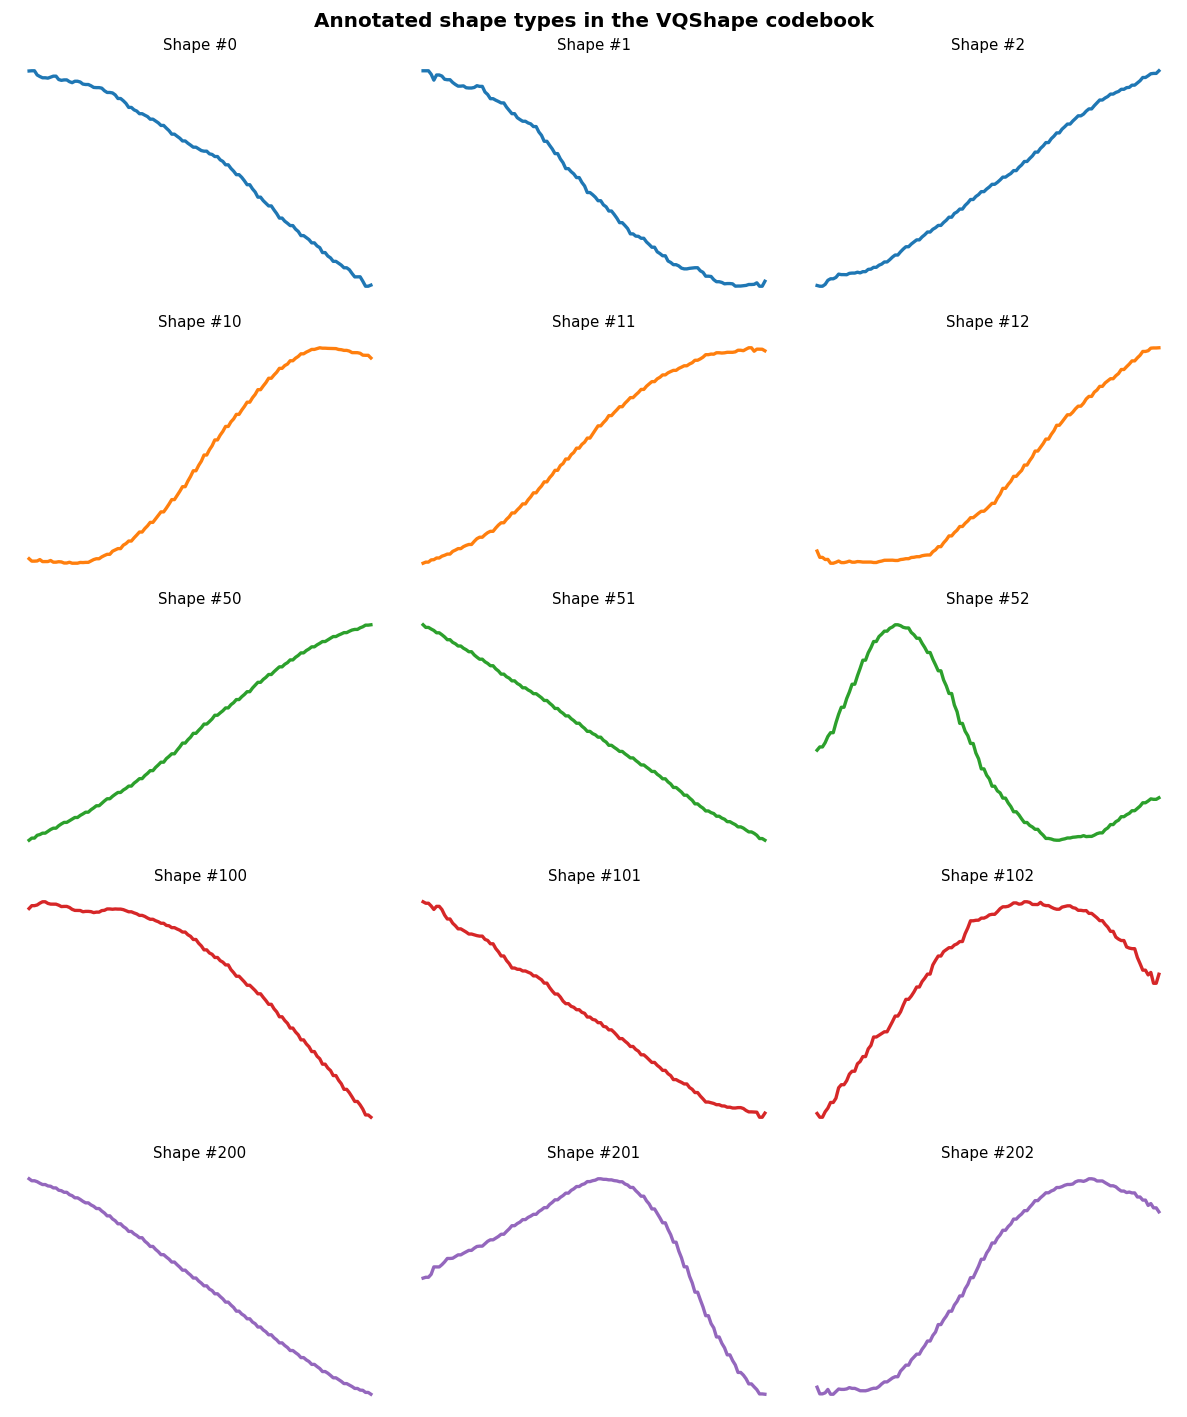

In [17]:
# ── Cell 3.4 — Highlight notable shapes ──────────────────────────────────
#
# Manually pick a few interesting shape types to annotate.
# Run Cell 3.3 first, then look at the grid and note:
#   - Which indices look like peaks?
#   - Which look like descents?
#   - Which look like flat lines?
# Replace the indices below with what you actually observe.

# These are example indices — update after looking at your codebook grid
example_shapes = {
    'Sharp spike (QRS-like)':  [0, 1, 2],
    'Smooth bump (P/T-wave)':  [10, 11, 12],
    'Flat plateau':            [50, 51, 52],
    'Descending ramp':         [100, 101, 102],
    'Oscillation':             [200, 201, 202],
}

fig, axes = plt.subplots(len(example_shapes), 3, figsize=(10, 12))

for row_idx, (label, indices) in enumerate(example_shapes.items()):
    for col_idx, sh_idx in enumerate(indices):
        ax = axes[row_idx, col_idx]
        ax.plot(shapes[sh_idx], linewidth=2.0, color=plt.cm.tab10(row_idx))
        ax.set_title(f'Shape #{sh_idx}', fontsize=9)
        ax.axis('off')
    axes[row_idx, 0].set_ylabel(label, fontsize=9, rotation=0,
                                 labelpad=100, va='center')

plt.suptitle('Annotated shape types in the VQShape codebook',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/04_annotated_shapes.png', bbox_inches='tight')
plt.show()

In [18]:
# ── Cell 4.1 — Tokenization function ─────────────────────────────────────
#
# What happens inside tokenize():
#   1. Interpolate signal from T=1000 → T=512  (VQShape requires exactly 512)
#   2. Rearrange (B, C, 512) → (B*C, 512)      (process each lead independently)
#   3. Pass through VQShape encoder              (patch → embed → quantize)
#   4. For each of the 64 patches, find the nearest codebook entry
#   5. Return token_ids (which shape), quantized (the shape vector)
#
# Output shapes (confirmed from your benchmark run):
#   token_ids  : (N, C, 64)       ← which codebook shape per patch per lead
#   tokens     : (N, C, 64, D)    ← the actual shape vectors (D inferred)
#   histograms : (N, C, 512)      ← how often each shape appears (bag-of-shapes)
#
# The histogram is the most compact representation:
#   "This ECG uses shape #42 in 8/64 patches of Lead I" → hist[0, 0, 42] = 0.125

@torch.no_grad()
def tokenize(model, signals_npy: np.ndarray,
             device: str = 'cpu', batch_size: int = 64) -> dict:
    N, T, C = signals_npy.shape
    all_ids, all_tok, all_hist = [], [], []

    for i in tqdm(range(0, N, batch_size), desc='Tokenizing', leave=True):
        batch = signals_npy[i:i+batch_size]      # (B, 1000, 12)
        B     = batch.shape[0]

        # Step 1: channels-first → (B, 12, 1000)
        x = torch.tensor(batch).permute(0, 2, 1)

        # Step 2: interpolate to 512 (required by VQShape)
        x = F.interpolate(x, size=NORMALIZE_LEN,
                          mode='linear', align_corners=False)  # (B, 12, 512)

        # Step 3: flatten to univariate for VQShape
        x_uni = rearrange(x, 'b c t -> (b c) t').to(device)  # (B*12, 512)

        # Step 4: tokenize
        out = model(x_uni, mode='tokenize')
        if isinstance(out, tuple):
            _, output_dict = out
        else:
            output_dict = out

        # output_dict['code_idx'] : (B*12, n_tokens) — codebook index per token
        # output_dict['code']     : (B*12, n_tokens, D) — quantized embedding per token
        n_tokens = output_dict['code_idx'].shape[1]
        code_dim = output_dict['code'].shape[-1]
        ids = output_dict['code_idx'].cpu().numpy().reshape(B, C, n_tokens)     # (B, 12, n_tokens)
        tok = output_dict['code'].cpu().numpy().reshape(B, C, n_tokens, code_dim)  # (B, 12, n_tokens, D)

        # Step 5: build bag-of-shapes histogram
        hist = np.zeros((B, C, CODEBOOK_SIZE), dtype=np.float32)
        for b in range(B):
            for c in range(C):
                for tok_id in ids[b, c]:
                    hist[b, c, tok_id] += 1
        hist /= n_tokens    # normalize: sum per (sample, channel) = 1.0

        all_ids.append(ids)
        all_tok.append(tok)
        all_hist.append(hist)

    return {
        'token_ids':  np.concatenate(all_ids,  axis=0),   # (N, 12, n_tokens)
        'tokens':     np.concatenate(all_tok,  axis=0),   # (N, 12, n_tokens, D)
        'histograms': np.concatenate(all_hist, axis=0),   # (N, 12, 512)
    }

print("Tokenization function defined.")

Tokenization function defined.


In [19]:
# ── Cell 4.2 — Quick shape verification ──────────────────────────────────
#
# Always test on 10 samples first before running on 21k.
# Verify the output shapes match your benchmark:
#   tokens     should be (10, 12, 64, DIM_CODE)  ← matches benchmark (N, C, 64, D)
#   histograms should be (10, 12, 512)           ← matches benchmark (N, C, 512)

test_out = tokenize(vqs_model, X_te[:10], device=DEVICE, batch_size=10)

print("Output shapes (should match benchmark):")
print(f"  token_ids  : {test_out['token_ids'].shape}   ← expect (10, 12, 64)")
print(f"  tokens     : {test_out['tokens'].shape}  ← expect (10, 12, 64, {DIM_CODE})")
print(f"  histograms : {test_out['histograms'].shape}   ← expect (10, 12, 512)")

# Verify histogram sums to 1.0 per (sample, channel)
hist_sums = test_out['histograms'].sum(axis=-1)   # (10, 12)
print(f"\nHistogram row sums (all should be 1.0):")
print(f"  min={hist_sums.min():.4f}, max={hist_sums.max():.4f}")

Tokenizing: 100%|██████████| 1/1 [00:01<00:00,  1.42s/it]

Output shapes (should match benchmark):
  token_ids  : (10, 12, 64)   ← expect (10, 12, 64)
  tokens     : (10, 12, 64, 8)  ← expect (10, 12, 64, 8)
  histograms : (10, 12, 512)   ← expect (10, 12, 512)

Histogram row sums (all should be 1.0):
  min=1.0000, max=1.0000


In [20]:
# ── Cell 4.3 — Tokenize all splits ───────────────────────────────────────
#
# Tokenize train, val, and test sets in full.
# Time estimates:
#   CPU:  ~8 min per 2000 samples  (full 17k train ≈ 70 min)
#   GPU:  ~1-2 min per 2000 samples (full 17k ≈ 10 min)
#
# For the demo/notebook: use N_DEMO=2000 for train to save time.
# For final results: set N_DEMO = len(X_tr)  (all 17 400)
#
# We tokenize the full test set always (2200 samples, fast).

N_DEMO = 2000    # ← increase to len(X_tr) for full training

print(f"Tokenizing train (first {N_DEMO} samples) ...")
tok_tr  = tokenize(vqs_model, X_tr[:N_DEMO],  device=DEVICE, batch_size=64)

print(f"Tokenizing val ...")
tok_val = tokenize(vqs_model, X_val,           device=DEVICE, batch_size=64)

print(f"Tokenizing test ...")
tok_te  = tokenize(vqs_model, X_te,            device=DEVICE, batch_size=64)

print(f"\nTrain tokens : {tok_tr['token_ids'].shape}")
print(f"Val   tokens : {tok_val['token_ids'].shape}")
print(f"Test  tokens : {tok_te['token_ids'].shape}")

Tokenizing train (first 2000 samples) ...


Tokenizing: 100%|██████████| 32/32 [01:21<00:00,  2.54s/it]


Tokenizing val ...


Tokenizing: 100%|██████████| 35/35 [01:17<00:00,  2.20s/it]


Tokenizing test ...


Tokenizing: 100%|██████████| 35/35 [01:17<00:00,  2.21s/it]


Train tokens : (2000, 12, 64)
Val   tokens : (2183, 12, 64)
Test  tokens : (2198, 12, 64)


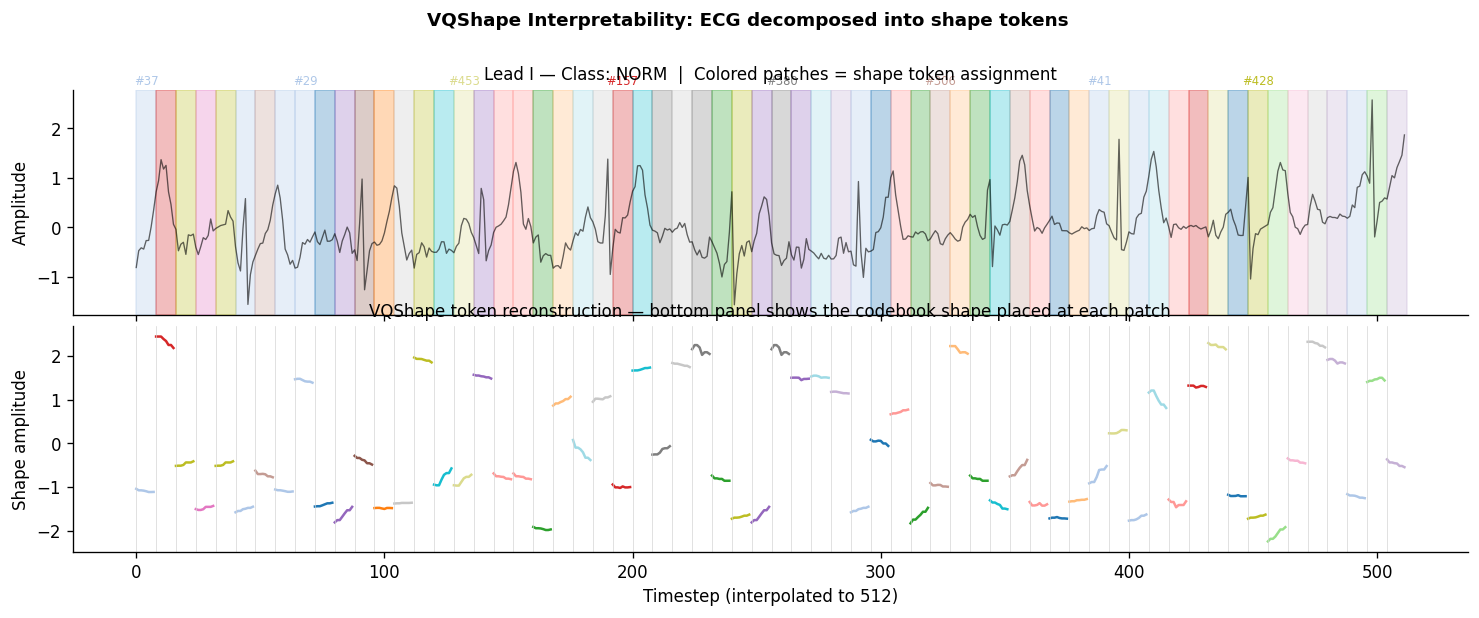

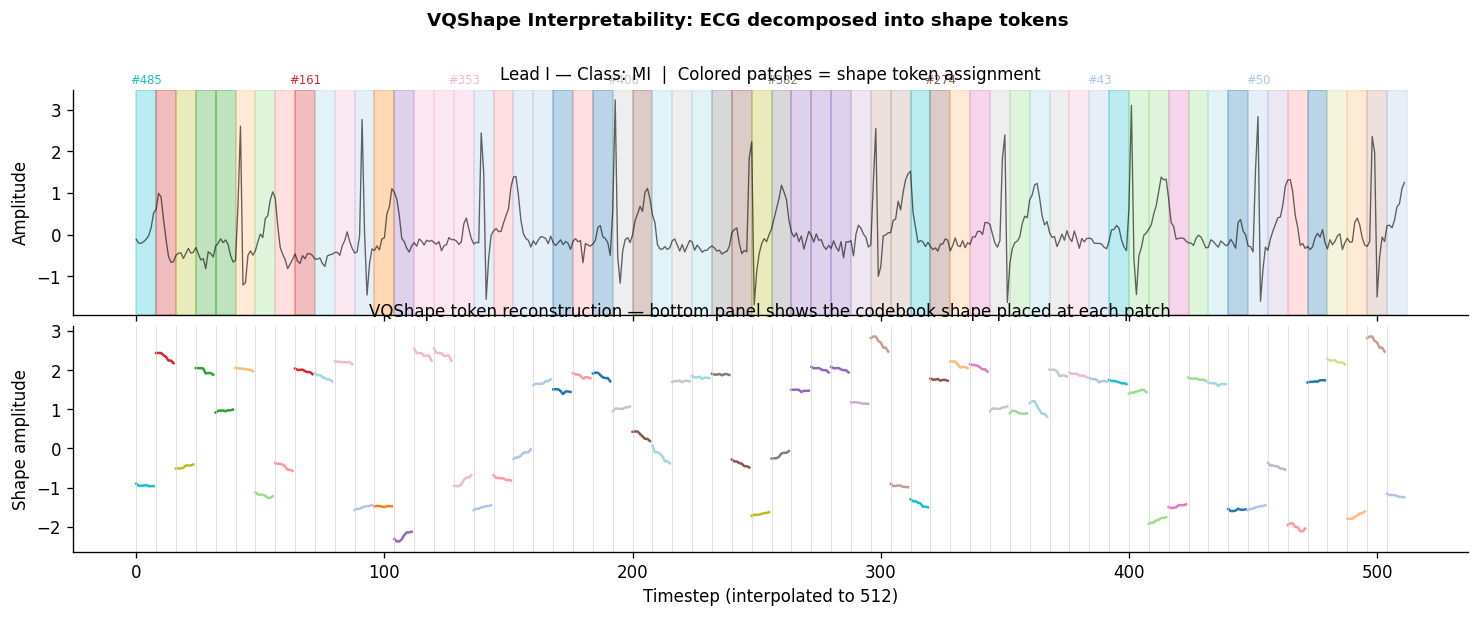

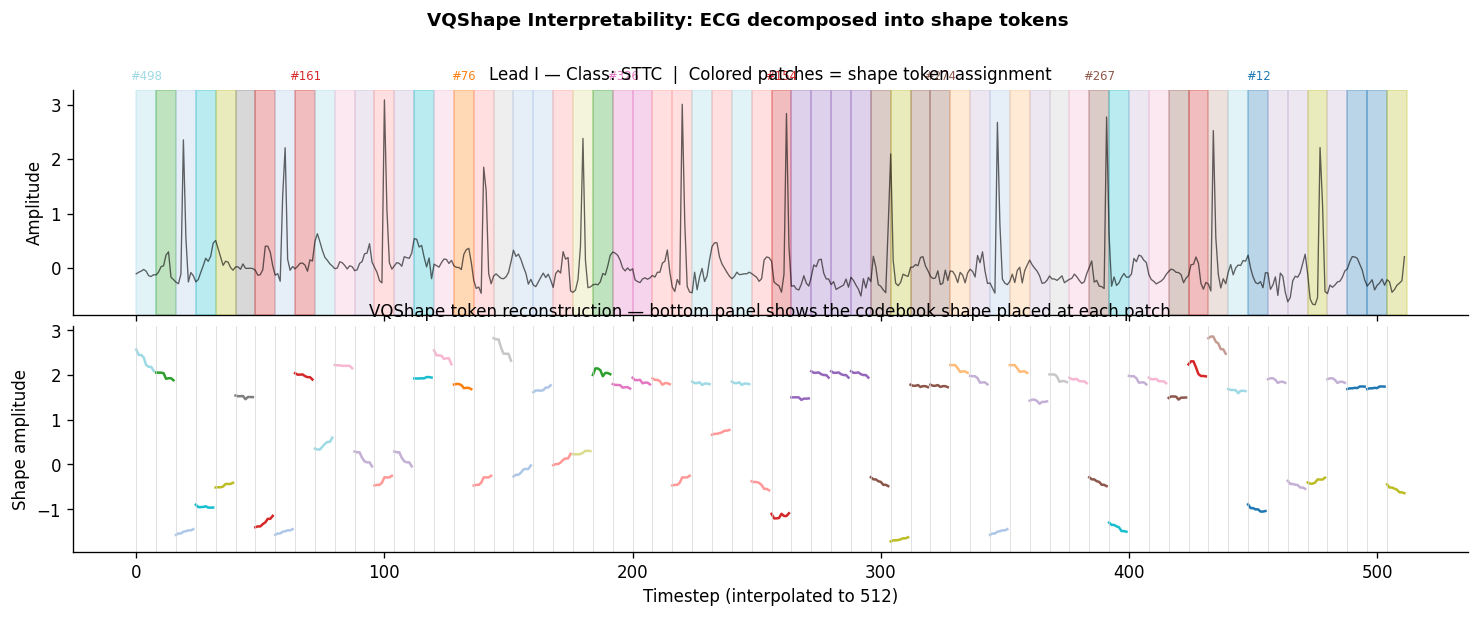

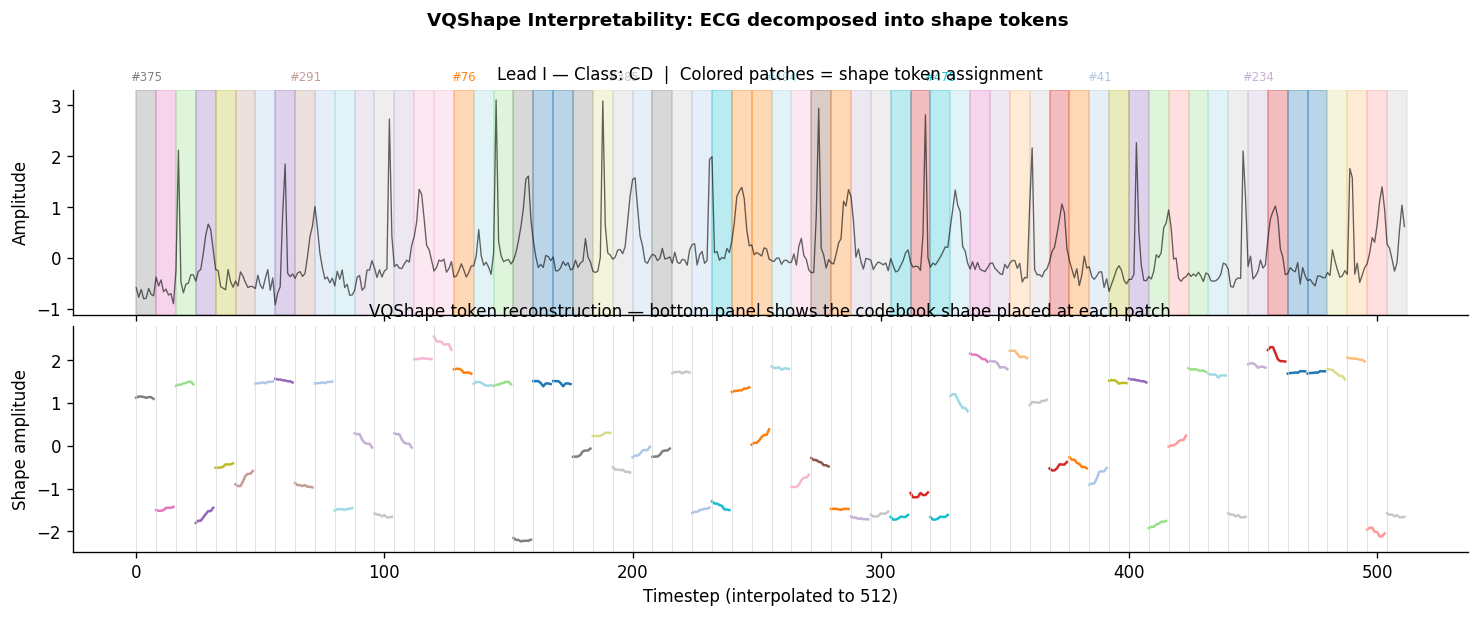

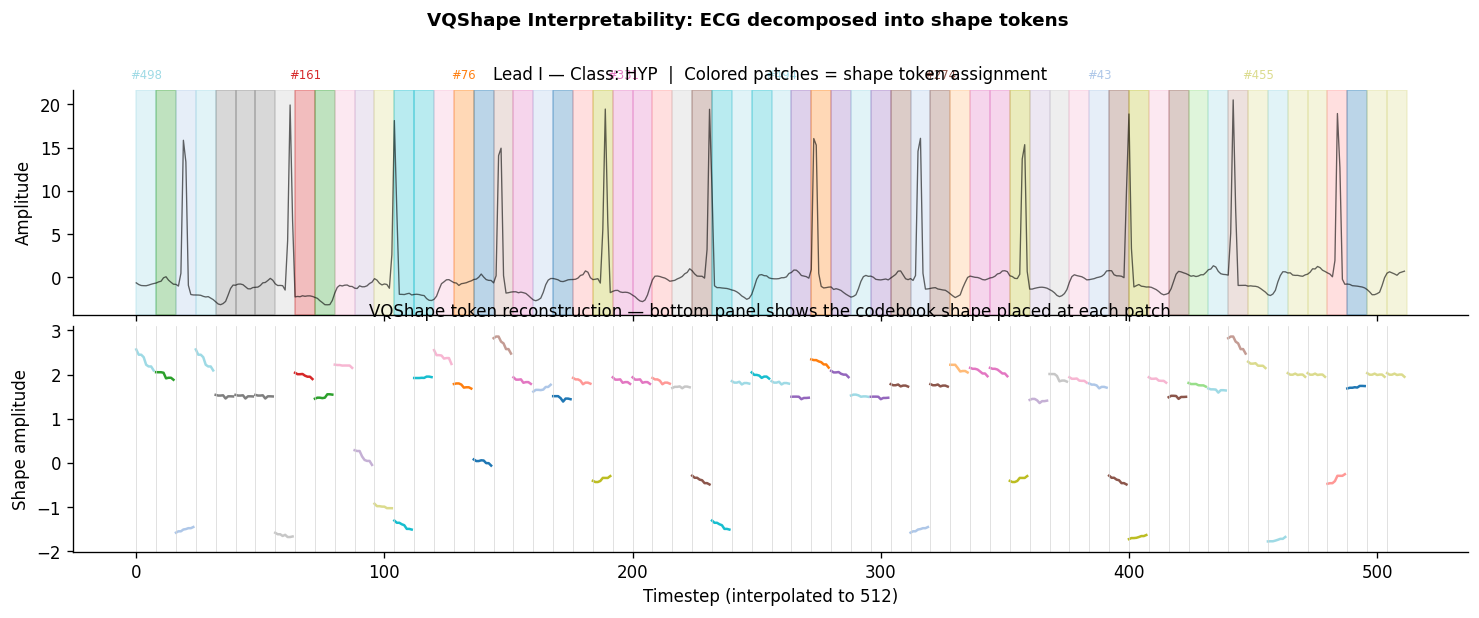

In [22]:
# ── Cell 5.1 — Tokenization visualization for one sample ─────────────────
#
# Two-panel figure:
#   Top:    raw ECG signal (Lead I) with patches colored by token ID
#   Bottom: the corresponding codebook shape placed in each patch window
#
# How to read it:
#   - Patches with the SAME color = same shape token = same waveform pattern
#   - The bottom panel shows what the model "thinks" each segment looks like
#   - When top and bottom align well, the tokenization is faithful

def plot_ecg_tokens(signal_1000: np.ndarray, token_ids_64: np.ndarray,
                    shapes_K8: np.ndarray, class_name: str,
                    save_path: str = None):
    """
    signal_1000   : (1000,) raw normalized Lead I
    token_ids_64  : (64,)   integer token IDs for Lead I
    shapes_K8     : (K, 8)  full codebook
    """
    # Interpolate signal to 512 for alignment with patches
    sig_512 = F.interpolate(
        torch.tensor(signal_1000).unsqueeze(0).unsqueeze(0).float(),
        512, mode='linear', align_corners=False
    ).squeeze().numpy()

    K = shapes_K8.shape[0]
    if hasattr(cm, 'get_cmap'):
        cmap = cm.get_cmap('tab20', K)
    else:
        import matplotlib as mpl
        base_cmap = mpl.colormaps['tab20']
        cmap = base_cmap.resampled(K) if hasattr(base_cmap, 'resampled') else base_cmap

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True,
                                    gridspec_kw={'hspace': 0.05})

    # Top: raw signal, patches colored
    ax1.plot(sig_512, color='black', linewidth=0.8, alpha=0.6)
    for p_idx, tok in enumerate(token_ids_64):
        start = p_idx * 8    # patch_length = 512/64 = 8
        ax1.axvspan(start, start + 8, alpha=0.3, color=cmap(tok))
        # label every 8th patch (every 64 timesteps)
        if p_idx % 8 == 0:
            ax1.text(start + 4, sig_512.max() * 1.12,
                     f'#{tok}', fontsize=7, ha='center', color=cmap(tok))
    ax1.set_ylabel('Amplitude')
    ax1.set_title(f'Lead I — Class: {class_name}  |  Colored patches = shape token assignment',
                  fontsize=10)

    # Bottom: codebook shape reconstruction
    for p_idx, tok in enumerate(token_ids_64):
        start  = p_idx * 8
        x_plot = np.arange(start, start + 8)
        y_plot = shapes_K8[tok][:8]
        ax2.plot(x_plot, y_plot, color=cmap(tok), linewidth=1.5)
        ax2.axvline(start, color='lightgray', linewidth=0.4)

    ax2.set_ylabel('Shape amplitude')
    ax2.set_xlabel('Timestep (interpolated to 512)')
    ax2.set_title('VQShape token reconstruction — bottom panel shows the codebook shape placed at each patch',
                  fontsize=10)

    plt.suptitle('VQShape Interpretability: ECG decomposed into shape tokens',
                 fontsize=11, fontweight='bold', y=1.01)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=130)
    return fig


# Visualize one sample from each class
fig, _ = plt.subplots()   # dummy
plt.close()

for c in range(N_CLASSES):
    s_idx = np.where(y_te == c)[0][0]
    fig = plot_ecg_tokens(
        signal_1000   = X_te[s_idx, :, 0],                     # Lead I
        token_ids_64  = tok_te['token_ids'][s_idx, 0],          # Lead I tokens
        shapes_K8     = shapes,
        class_name    = CLASS_NAMES[c],
        save_path     = f'{OUTPUTS_DIR}/05_tokens_{CLASS_NAMES[c]}.png'
    )
    plt.show()
    plt.close()

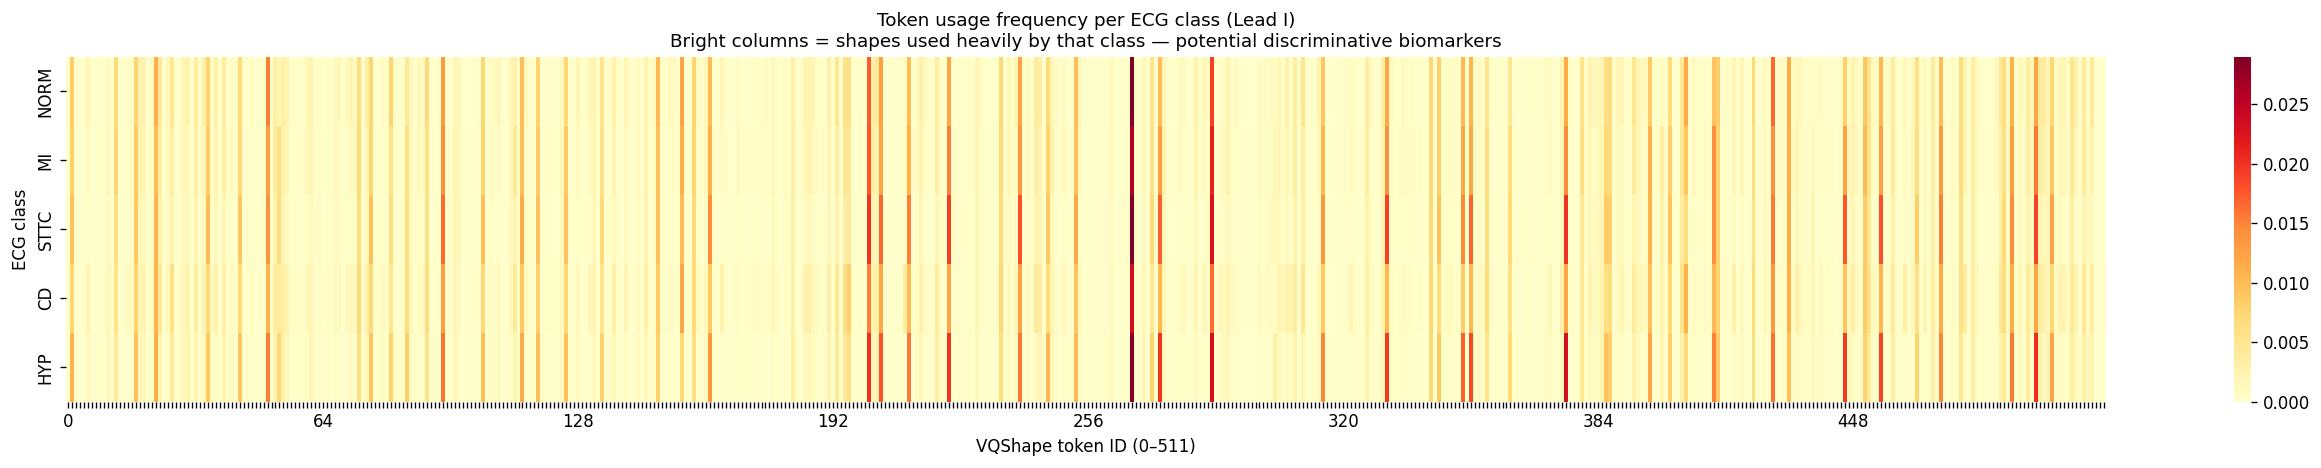

In [23]:
# ── Cell 5.2 — Token frequency heatmap ───────────────────────────────────
#
# Heatmap: rows = ECG class, columns = token ID (0-511)
# Color = how often this class uses this token (normalized frequency)
#
# Hot columns = discriminative shape tokens:
#   A token used heavily by MI but rarely by NORM is a potential
#   biomarker — a shape that appears specifically in ischemic hearts.
# This analysis is the key scientific insight of your project.

# Use Lead I (index 0) for this analysis
freq_matrix = np.zeros((N_CLASSES, CODEBOOK_SIZE), dtype=np.float32)
for c in range(N_CLASSES):
    mask = y_te == c
    if mask.sum() > 0:
        # Flatten all patches across all test samples of this class
        toks = tok_te['token_ids'][mask, 0, :].flatten()   # Lead I
        for t in toks:
            freq_matrix[c, t] += 1
        freq_matrix[c] /= freq_matrix[c].sum()

fig, ax = plt.subplots(figsize=(22, 4))
sns.heatmap(freq_matrix, ax=ax, cmap='YlOrRd',
            xticklabels=[str(i) if i % 64 == 0 else '' for i in range(CODEBOOK_SIZE)],
            yticklabels=CLASS_NAMES,
            linewidths=0, rasterized=True)
ax.set_title(
    'Token usage frequency per ECG class (Lead I)\n'
    'Bright columns = shapes used heavily by that class — potential discriminative biomarkers',
    fontsize=11
)
ax.set_xlabel(f'VQShape token ID (0–{CODEBOOK_SIZE-1})')
ax.set_ylabel('ECG class')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/06_token_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

Top 5 most discriminative tokens per class:

  NORM → tokens [217, 200, 263, 149, 122]
         ratios ['9635.15x', '3211.72x', '1605.86x', '4.33x', '4.33x']

  MI   → tokens [27, 66, 69, 231, 209]
         ratios ['3801.70x', '3801.70x', '3801.70x', '28.41x', '9.47x']

  STTC → tokens [181, 415, 374, 358, 404]
         ratios ['33.36x', '13.21x', '11.12x', '10.93x', '9.63x']

  CD   → tokens [444, 169, 477, 379, 0]
         ratios ['8903.13x', '4451.57x', '44.35x', '16.63x', '11.09x']

  HYP  → tokens [252, 6, 474, 119, 139]
         ratios ['14.55x', '14.55x', '9.13x', '7.89x', '6.31x']



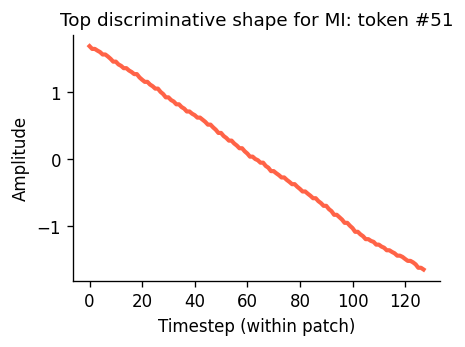

In [24]:
# ── Cell 5.3 — Most discriminative tokens ────────────────────────────────
#
# For each class, find the tokens used MOST by that class compared to others.
# Metric: freq_for_class / mean_freq_across_other_classes
#   → high value = this token is specifically used by this class

print("Top 5 most discriminative tokens per class:\n")
for c in range(N_CLASSES):
    other_mean = np.mean(freq_matrix[np.arange(N_CLASSES) != c], axis=0)
    # avoid division by zero
    other_mean = np.where(other_mean == 0, 1e-8, other_mean)
    ratio      = freq_matrix[c] / other_mean
    top5       = np.argsort(ratio)[::-1][:5]
    print(f"  {CLASS_NAMES[c]:4s} → tokens {top5.tolist()}")
    print(f"         ratios {[f'{ratio[i]:.2f}x' for i in top5]}")
    print()

# These tokens are the "shape biomarkers" of each class.
# Visualize the top token for MI:
mi_top_token = np.argsort(freq_matrix[1] / np.mean(freq_matrix[[0,2,3,4]], axis=0))[-1]
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(shapes[mi_top_token], linewidth=2.5, color='tomato')
ax.set_title(f'Top discriminative shape for MI: token #{mi_top_token}', fontsize=11)
ax.set_xlabel('Timestep (within patch)')
ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/07_mi_discriminative_shape.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Cell 6.1 — Linear probe ───────────────────────────────────────────────
#
# Flatten histograms: (N, 12, 512) → (N, 12*512=6144)
# Each sample is described as "how often each of 512 shapes appears in each lead"
#
# If a simple linear model does well on these features, it means the
# shape representation is linearly separable — a strong result.

def flatten_histograms(hists: np.ndarray) -> np.ndarray:
    """(N, C, K) → (N, C*K)"""
    N, C, K = hists.shape
    return hists.reshape(N, C * K)

X_feat_tr  = flatten_histograms(tok_tr['histograms'])          # (N_DEMO, 6144)
X_feat_val = flatten_histograms(tok_val['histograms'])
X_feat_te  = flatten_histograms(tok_te['histograms'])

print(f"Feature shape (train): {X_feat_tr.shape}")

# Logistic regression with L2 regularization
clf = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced',
                         solver='lbfgs', multi_class='multinomial', n_jobs=-1)
clf.fit(X_feat_tr, y_tr[:N_DEMO])

y_pred_te = clf.predict(X_feat_te)

print(f"\nLinear probe — Test accuracy: {(y_pred_te == y_te).mean():.3f}\n")
print(classification_report(y_te, y_pred_te, target_names=CLASS_NAMES))

Feature shape (train): (2000, 6144)

Linear probe — Test accuracy: 0.417

              precision    recall  f1-score   support

        NORM       0.69      0.53      0.60       973
          MI       0.36      0.19      0.25       411
        STTC       0.37      0.25      0.30       350
          CD       0.36      0.52      0.43       351
         HYP       0.11      0.49      0.18       113

    accuracy                           0.42      2198
   macro avg       0.38      0.40      0.35      2198
weighted avg       0.50      0.42      0.44      2198



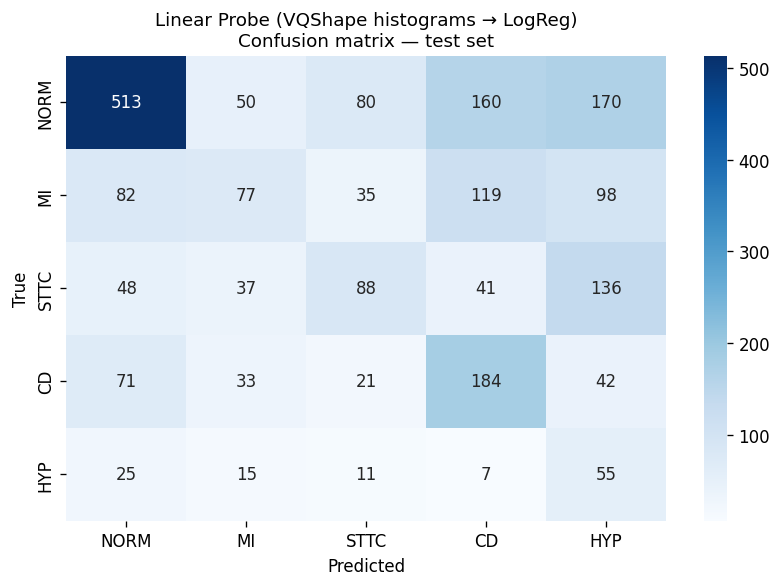

In [26]:
# ── Cell 6.2 — Confusion matrix ──────────────────────────────────────────

cm_matrix = confusion_matrix(y_te, y_pred_te)
fig, ax   = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Linear Probe (VQShape histograms → LogReg)\nConfusion matrix — test set',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/08_confusion_matrix_probe.png', bbox_inches='tight')
plt.show()

In [27]:
# ── Cell 7.1 — InterpGN architecture ─────────────────────────────────────
#
# InterpGN has three components (ICLR 2025, Kim et al.):
#
#   1. INTERPRETABLE EXPERT
#      - Learns K shapelets (short trainable waveforms)
#      - Computes soft-min sliding-window distance from signal to each shapelet
#      - Linear classifier on these K distances → class logits
#      - Confidence head → how sure is this expert? (0-1 scalar)
#
#   2. DEEP EXPERT
#      - MLP on the flattened VQShape histogram features (6144-dim)
#      - Handles complex patterns the shapelet expert cannot express
#
#   3. GATING FUNCTION
#      - g = sigmoid(α × (confidence - τ))   where τ=0.5, α=10
#      - g ≈ 1.0 → use interpretable expert's prediction
#      - g ≈ 0.0 → use deep expert's prediction
#      - Final: ŷ = g × interp_logits + (1-g) × deep_logits
#
# Why does this matter clinically?
#   When g ≈ 1.0, we can say EXACTLY which shapelets fired.
#   "Prediction = MI because shapelet #3 (↓ ST-segment shape) matched
#    at position 420ms and shapelet #7 did NOT match."
#   This is the kind of explanation doctors and regulators need.

class ShapeletLayer(nn.Module):
    def __init__(self, n_shapelets: int = 30, patch_len: int = 8):
        super().__init__()
        # Initialize shapelets as copies of random codebook shapes
        # (better than random Gaussian initialization)
        self.shapelets = nn.Parameter(torch.randn(n_shapelets, patch_len) * 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 512)
        # Sliding window: step=1, window=patch_len
        L = self.shapelets.shape[1]
        windows = x.unfold(1, L, 1)                         # (B, 505, L)
        S = self.shapelets.unsqueeze(0).unsqueeze(0)        # (1, 1, K, L)
        W = windows.unsqueeze(2)                            # (B, 505, 1, L)
        dist = ((W - S) ** 2).mean(dim=-1)                  # (B, 505, K)
        # Soft-min (differentiable): sharper = more like hard-min
        dist_min = -torch.logsumexp(-dist * 5.0, dim=1)    # (B, K)
        return dist_min

class InterpretableExpert(nn.Module):
    def __init__(self, n_shapelets: int, n_classes: int):
        super().__init__()
        self.shapelet_layer  = ShapeletLayer(n_shapelets)
        self.classifier      = nn.Linear(n_shapelets, n_classes)
        self.confidence_head = nn.Sequential(
            nn.Linear(n_shapelets, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, x):
        d = self.shapelet_layer(x)
        return self.classifier(d), self.confidence_head(d).squeeze(-1)

class DeepExpert(nn.Module):
    def __init__(self, input_dim: int, n_classes: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
    def forward(self, x): return self.mlp(x)

class InterpGN(nn.Module):
    def __init__(self, n_shapelets=30, n_classes=5,
                 n_channels=12, codebook_size=512,
                 tau=0.5, alpha=10.0):
        super().__init__()
        self.interp = InterpretableExpert(n_shapelets, n_classes)
        self.deep   = DeepExpert(n_channels * codebook_size, n_classes)
        self.tau    = tau
        self.alpha  = alpha

    def forward(self, x_sig, x_hist):
        # x_sig:  (B, 512)   — Lead I interpolated
        # x_hist: (B, 6144)  — flattened histograms all leads
        il, conf = self.interp(x_sig)
        dl       = self.deep(x_hist)
        gate     = torch.sigmoid(self.alpha * (conf - self.tau))   # (B,)
        g        = gate.unsqueeze(-1)
        return {
            'logits':        g * il + (1 - g) * dl,
            'interp_logits': il,
            'deep_logits':   dl,
            'gate':          gate,
            'confidence':    conf,
        }

print("InterpGN architecture defined.")

InterpGN architecture defined.


In [28]:
# ── Cell 7.2 — Dataset and DataLoader ────────────────────────────────────
#
# For each sample we need three things:
#   x_signal:    Lead I at 512 timesteps  → input to shapelet layer
#   x_histogram: all 12 leads flattened   → input to deep expert
#   label:       integer 0-4

class ECGDataset(Dataset):
    def __init__(self, signals, histograms, labels):
        N, T, C = signals.shape
        # Lead I (channel 0), interpolate to 512
        x = torch.tensor(signals[:, :, 0], dtype=torch.float32)  # (N, 1000)
        self.x_sig  = F.interpolate(
            x.unsqueeze(1), NORMALIZE_LEN, mode='linear', align_corners=False
        ).squeeze(1)                                               # (N, 512)
        # Flatten histograms
        self.x_hist = torch.tensor(
            histograms.reshape(len(labels), -1), dtype=torch.float32   # (N, 6144)
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return self.x_sig[i], self.x_hist[i], self.labels[i]


train_ds = ECGDataset(X_tr[:N_DEMO],  tok_tr['histograms'],  y_tr[:N_DEMO])
val_ds   = ECGDataset(X_val,          tok_val['histograms'], y_val)
test_ds  = ECGDataset(X_te,           tok_te['histograms'],  y_te)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)

print(f"Train dataset : {len(train_ds)} samples")
print(f"Val   dataset : {len(val_ds)} samples")
print(f"Test  dataset : {len(test_ds)} samples")

Train dataset : 2000 samples
Val   dataset : 2183 samples
Test  dataset : 2198 samples


In [29]:
# ── Cell 7.3 — Training loop ──────────────────────────────────────────────
#
# Loss = CE(blended logits, y)
#      + 0.3 × CE(interp logits, y)    ← auxiliary: shapelet expert must learn too
#
# The 0.3 weight is from the paper. It prevents the gating function from
# routing everything to the deep expert and ignoring shapelets.
#
# Training time estimate:
#   CPU: ~2-3 min per epoch  → 20 epochs ≈ 45 min
#   GPU: ~15 sec per epoch   → 20 epochs ≈ 5 min

interpgn = InterpGN(
    n_shapelets  = 30,
    n_classes    = N_CLASSES,
    n_channels   = N_CHANNELS,
    codebook_size= CODEBOOK_SIZE,
    tau          = 0.5,
    alpha        = 10.0
).to(DEVICE)

optimizer = torch.optim.Adam(interpgn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

history = {'train_loss': [], 'val_acc': [], 'interp_rate': []}

N_EPOCHS = 20
for epoch in range(N_EPOCHS):
    # ── Train ──
    interpgn.train()
    ep_loss = 0.0
    for sig, hist, lbl in train_dl:
        sig, hist, lbl = sig.to(DEVICE), hist.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        out  = interpgn(sig, hist)
        loss = (F.cross_entropy(out['logits'],        lbl) +
                0.3 * F.cross_entropy(out['interp_logits'], lbl))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(interpgn.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item()
    scheduler.step()

    # ── Validate ──
    interpgn.eval()
    n_correct = n_total = n_interp = 0
    with torch.no_grad():
        for sig, hist, lbl in val_dl:
            sig, hist, lbl = sig.to(DEVICE), hist.to(DEVICE), lbl.to(DEVICE)
            out = interpgn(sig, hist)
            n_correct += (out['logits'].argmax(-1) == lbl).sum().item()
            n_total   += lbl.size(0)
            n_interp  += (out['gate'] > 0.5).sum().item()

    acc   = n_correct / n_total
    rate  = n_interp  / n_total
    avg_loss = ep_loss / len(train_dl)
    history['train_loss'].append(avg_loss)
    history['val_acc'].append(acc)
    history['interp_rate'].append(rate)

    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | "
          f"loss={avg_loss:.4f} | "
          f"val_acc={acc:.3f} | "
          f"interp_rate={rate:.2%}")

Epoch  1/20 | loss=1.6419 | val_acc=0.443 | interp_rate=0.00%
Epoch  2/20 | loss=0.8055 | val_acc=0.449 | interp_rate=0.00%
Epoch  3/20 | loss=0.4920 | val_acc=0.537 | interp_rate=0.00%
Epoch  4/20 | loss=0.4297 | val_acc=0.538 | interp_rate=0.00%
Epoch  5/20 | loss=0.4055 | val_acc=0.526 | interp_rate=0.00%
Epoch  6/20 | loss=0.4086 | val_acc=0.537 | interp_rate=0.00%
Epoch  7/20 | loss=0.3933 | val_acc=0.543 | interp_rate=0.00%
Epoch  8/20 | loss=0.3901 | val_acc=0.541 | interp_rate=0.00%
Epoch  9/20 | loss=0.3883 | val_acc=0.546 | interp_rate=0.00%
Epoch 10/20 | loss=0.3875 | val_acc=0.550 | interp_rate=0.00%
Epoch 11/20 | loss=0.3845 | val_acc=0.547 | interp_rate=0.00%
Epoch 12/20 | loss=0.3867 | val_acc=0.555 | interp_rate=0.00%
Epoch 13/20 | loss=0.3873 | val_acc=0.550 | interp_rate=0.00%
Epoch 14/20 | loss=0.3836 | val_acc=0.551 | interp_rate=0.00%
Epoch 15/20 | loss=0.3838 | val_acc=0.549 | interp_rate=0.00%
Epoch 16/20 | loss=0.3831 | val_acc=0.546 | interp_rate=0.00%
Epoch 17

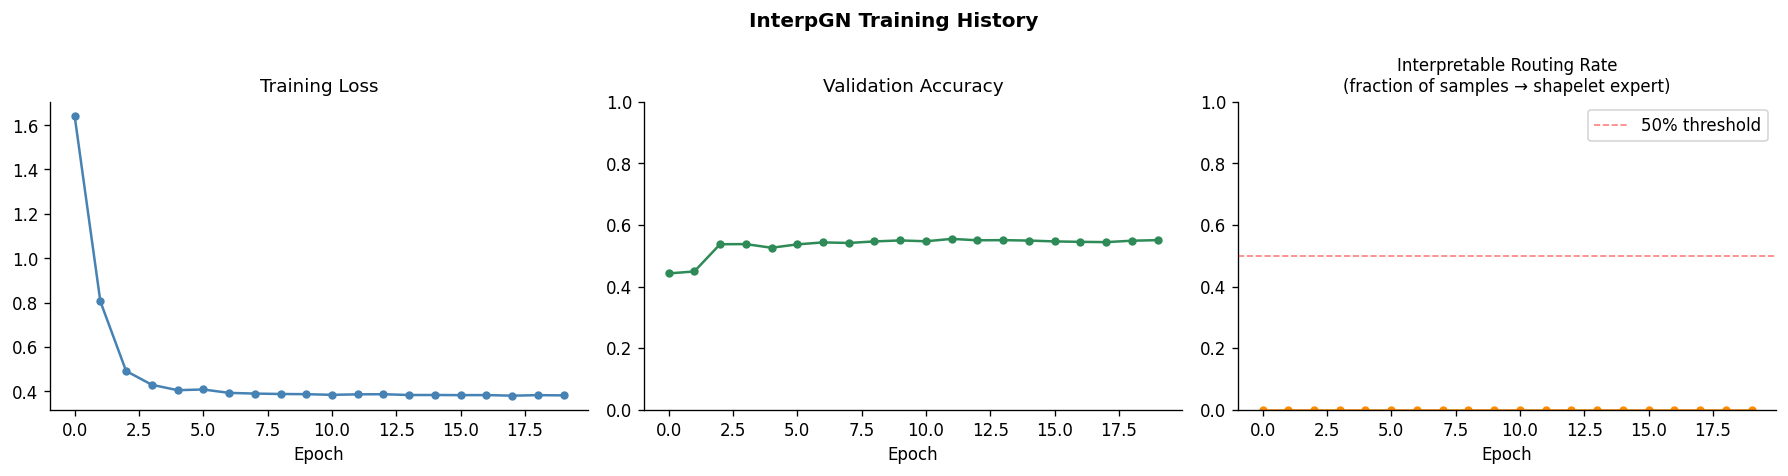

In [30]:
# ── Cell 7.4 — Training curves ────────────────────────────────────────────
#
# Watch for:
#   - interp_rate converging to a stable value (usually 30-70%)
#   - val_acc increasing steadily (not stuck)
#   - loss decreasing smoothly (if spiky, reduce lr to 3e-4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], marker='o', ms=4, color='steelblue')
axes[0].set_title('Training Loss', fontsize=11); axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_acc'], marker='o', ms=4, color='seagreen')
axes[1].set_title('Validation Accuracy', fontsize=11); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)

axes[2].plot(history['interp_rate'], marker='o', ms=4, color='darkorange')
axes[2].axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
axes[2].set_title('Interpretable Routing Rate\n(fraction of samples → shapelet expert)',
                   fontsize=10)
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1); axes[2].legend()

plt.suptitle('InterpGN Training History', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/09_training_curves.png', bbox_inches='tight')
plt.show()

In [31]:
# ── Cell 8.1 — Test set evaluation and routing ────────────────────────────

interpgn.eval()
all_preds, all_gates, all_conf = [], [], []

with torch.no_grad():
    for sig, hist, lbl in test_dl:
        sig, hist = sig.to(DEVICE), hist.to(DEVICE)
        out = interpgn(sig, hist)
        all_preds.append(out['logits'].argmax(-1).cpu().numpy())
        all_gates.append(out['gate'].cpu().numpy())
        all_conf.append(out['confidence'].cpu().numpy())

all_preds = np.concatenate(all_preds)
all_gates = np.concatenate(all_gates)
all_conf  = np.concatenate(all_conf)

# Overall accuracy
acc = (all_preds == y_te).mean()
interp_rate = (all_gates > 0.5).mean()

print(f"Test accuracy         : {acc:.3f}")
print(f"Interpretable routing : {interp_rate:.2%}")
print(f"Deep routing          : {1-interp_rate:.2%}")
print()
print(classification_report(y_te, all_preds, target_names=CLASS_NAMES))

Test accuracy         : 0.540
Interpretable routing : 0.00%
Deep routing          : 100.00%

              precision    recall  f1-score   support

        NORM       0.63      0.85      0.73       973
          MI       0.38      0.17      0.24       411
        STTC       0.44      0.42      0.43       350
          CD       0.45      0.37      0.41       351
         HYP       0.14      0.10      0.12       113

    accuracy                           0.54      2198
   macro avg       0.41      0.38      0.38      2198
weighted avg       0.50      0.54      0.50      2198



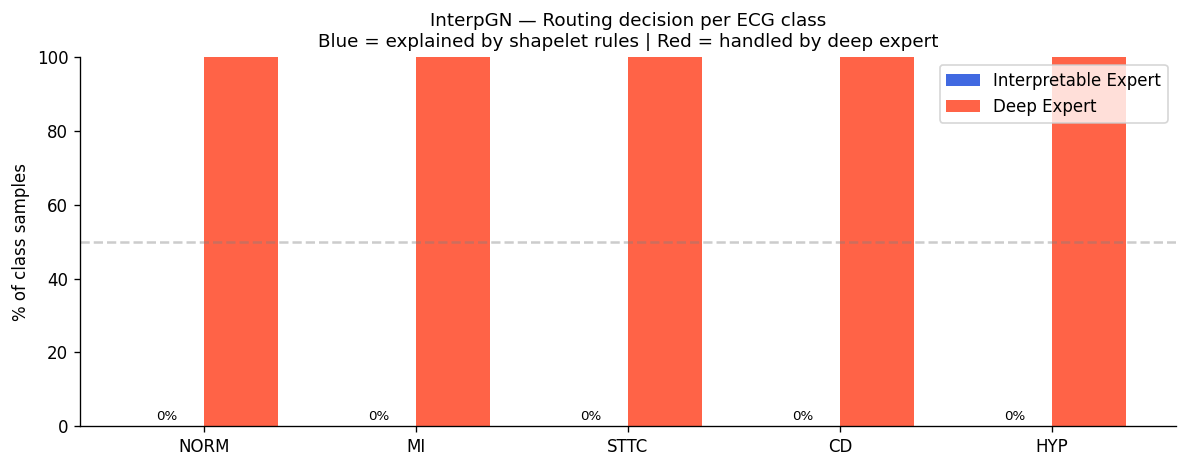

In [32]:
# ── Cell 8.2 — Routing by class ───────────────────────────────────────────
#
# Which ECG classes are "easy" (high interpretable routing)?
# Which are "hard" (mostly routed to deep expert)?
#
# Hypothesis:
#   NORM should have high interpretable routing — regular patterns
#   AF patterns inside STTC might have low routing — complex waveforms

fig, ax = plt.subplots(figsize=(10, 4))
w = 0.35
x = np.arange(N_CLASSES)

interp_counts = [(all_gates[y_te == c] > 0.5).sum() for c in range(N_CLASSES)]
deep_counts   = [(all_gates[y_te == c] <= 0.5).sum() for c in range(N_CLASSES)]
total_counts  = [(y_te == c).sum() for c in range(N_CLASSES)]

# Normalize to percentage
interp_pct = [i/t*100 for i, t in zip(interp_counts, total_counts)]
deep_pct   = [d/t*100 for d, t in zip(deep_counts,   total_counts)]

b1 = ax.bar(x - w/2, interp_pct, w, label='Interpretable Expert', color='royalblue')
b2 = ax.bar(x + w/2, deep_pct,   w, label='Deep Expert',          color='tomato')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('% of class samples'); ax.set_ylim(0, 100)
ax.set_title('InterpGN — Routing decision per ECG class\n'
             'Blue = explained by shapelet rules | Red = handled by deep expert', fontsize=11)
ax.legend()
ax.axhline(50, color='gray', linestyle='--', alpha=0.4)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/10_routing_per_class.png', bbox_inches='tight')
plt.show()

In [33]:
# ── Cell 8.3 — Per-sample explanations ───────────────────────────────────
#
# For samples with gate > 0.5, generate a text explanation:
# "Prediction = MI because shapelet #3 matched (d=0.0021) and
#  shapelet #17 matched (d=0.0034) but shapelet #9 did not (d=0.2100)"
#
# This is exactly what clinical AI explainability requires.

learned_shapelets = interpgn.interp.shapelet_layer.shapelets.detach().cpu().numpy()  # (30, 8)

def explain_sample(model, sig_tensor, hist_tensor, true_label: int) -> str:
    model.eval()
    with torch.no_grad():
        out   = model(sig_tensor.unsqueeze(0), hist_tensor.unsqueeze(0))
        dists = model.interp.shapelet_layer(sig_tensor.unsqueeze(0)).squeeze(0).cpu().numpy()

    pred  = out['logits'].argmax(-1).item()
    gate  = out['gate'].item()
    conf  = out['confidence'].item()
    route = 'Interpretable Expert' if gate > 0.5 else 'Deep Expert'
    correct = '✓' if pred == true_label else '✗'

    top3_matched   = np.argsort(dists)[:3]     # smallest distance = best match
    top3_unmatched = np.argsort(dists)[-3:]    # largest distance = no match

    lines = [
        f"True:  {CLASS_NAMES[true_label]}",
        f"Pred:  {CLASS_NAMES[pred]} {correct}",
        f"Route: {route}  (gate={gate:.3f}, confidence={conf:.3f})",
        "",
        "Shapelet evidence:",
        "  MATCHED (low distance = pattern present):",
    ]
    for i in top3_matched:
        lines.append(f"    Shapelet #{i:02d}  distance={dists[i]:.5f}")
    lines.append("  NOT MATCHED (high distance = pattern absent):")
    for i in top3_unmatched[::-1]:
        lines.append(f"    Shapelet #{i:02d}  distance={dists[i]:.5f}")
    return "\n".join(lines)


print("=" * 55)
for c in range(N_CLASSES):
    # Find a correctly predicted sample from this class
    class_mask    = (y_te == c)
    correct_mask  = (all_preds == y_te)
    interp_mask   = (all_gates > 0.5)
    combined      = class_mask & correct_mask & interp_mask
    candidates    = np.where(combined)[0]

    if len(candidates) == 0:
        print(f"{CLASS_NAMES[c]}: no correctly predicted interpretable sample found")
        continue

    idx = candidates[0]
    sig_t  = test_ds[idx][0].to(DEVICE)
    hist_t = test_ds[idx][1].to(DEVICE)

    print(f"\n{'─'*55}")
    print(f"CLASS: {CLASS_NAMES[c]}")
    print(explain_sample(interpgn, sig_t, hist_t, y_te[idx]))

print("\n" + "=" * 55)

NORM: no correctly predicted interpretable sample found
MI: no correctly predicted interpretable sample found
STTC: no correctly predicted interpretable sample found
CD: no correctly predicted interpretable sample found
HYP: no correctly predicted interpretable sample found



In [35]:
# ── Cell 9.1 — Two-level explanation figure (README hero image) ───────────
#
# This figure communicates the whole project in one image:
#
#   ROW 1: VQShape tokenization  (Level 1 interpretability)
#           Raw ECG → colored patches → shape token IDs
#
#   ROW 2: Top matched shapelets  (Level 2 interpretability)
#           Which shapelet patterns InterpGN found in the signal
#           + the gate/confidence routing decision
#
#   ROW 3: The codebook shapes used  (connects both levels)
#           Shows what the shape tokens actually look like

TARGET_CLASS = 1    # MI — most visually distinctive

# Find a correctly predicted MI sample that used the interpretable expert
mask = ((y_te == TARGET_CLASS) &
        (all_preds == y_te) &
        (all_gates > 0.5))
idx  = np.where(mask)[0][0]

sig_np   = test_ds[idx][0].numpy()     # (512,) Lead I
tids_np  = tok_te['token_ids'][idx, 0] # (64,)  Lead I token IDs
sig_t    = test_ds[idx][0].to(DEVICE).unsqueeze(0)
hist_t   = test_ds[idx][1].to(DEVICE).unsqueeze(0)

with torch.no_grad():
    out_ex   = interpgn(sig_t, hist_t)
    dists_np = interpgn.interp.shapelet_layer(sig_t).squeeze(0).cpu().numpy()

gate_val = out_ex['gate'].item()
conf_val = out_ex['confidence'].item()
pred_cls = out_ex['logits'].argmax(-1).item()
top3_sh  = np.argsort(dists_np)[:3]
if hasattr(cm, 'get_cmap'):
    cmap_tok = cm.get_cmap('tab20', CODEBOOK_SIZE)
else:
    import matplotlib as mpl
    base_cmap = mpl.colormaps['tab20']
    cmap_tok = base_cmap.resampled(CODEBOOK_SIZE) if hasattr(base_cmap, 'resampled') else base_cmap

# Build figure
fig = plt.figure(figsize=(18, 11))
gs  = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.35)

# ── Row 0: VQShape tokenization ──────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :])
ax0.plot(sig_np, color='black', linewidth=0.8, alpha=0.6)
for p_idx, tok in enumerate(tids_np):
    start = p_idx * 8
    ax0.axvspan(start, start + 8, alpha=0.3, color=cmap_tok(tok))
    if p_idx % 8 == 0:
        ax0.text(start + 4, sig_np.max() * 1.15,
                 f'#{tok}', fontsize=7, ha='center', color=cmap_tok(tok))
ax0.set_title(
    f'Level 1 — VQShape Tokenization  |  ECG Lead I  |  Class: {CLASS_NAMES[TARGET_CLASS]}',
    fontsize=10, fontweight='bold'
 )
ax0.set_ylabel('Amplitude'); ax0.set_xlabel('Timestep (interpolated to 512)')

# ── Row 1: Top 3 matched shapelets + gating ──────────────────────────────
for col, sh_idx in enumerate(top3_sh):
    ax = fig.add_subplot(gs[1, col])
    ax.plot(learned_shapelets[sh_idx], linewidth=2.5, color='tomato')
    ax.set_title(f'Matched Shapelet #{sh_idx}\ndist={dists_np[sh_idx]:.5f}',
                 fontsize=9)
    ax.set_xlabel('Shapelet timestep', fontsize=8)
    ax.tick_params(labelleft=False)

ax_gate = fig.add_subplot(gs[1, 3])
ax_gate.barh(['Gate', 'Confidence'], [gate_val, conf_val],
             color=['royalblue', 'seagreen'], edgecolor='white')
ax_gate.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='τ=0.5')
ax_gate.set_xlim(0, 1); ax_gate.legend(fontsize=8)
ax_gate.set_title(f'Level 2 — InterpGN Routing\nRoute: Interpretable Expert', fontsize=9, fontweight='bold')

# ── Row 2: Codebook shapes for dominant tokens ───────────────────────────
unique_toks = list(dict.fromkeys(tids_np.tolist()))[:4]
for col, tok in enumerate(unique_toks):
    ax = fig.add_subplot(gs[2, col])
    ax.plot(shapes[tok], linewidth=2.2, color=cmap_tok(tok))
    ax.set_title(f'Codebook Shape #{tok}\n(used in {(tids_np==tok).sum()}/64 patches)',
                 fontsize=9)
    ax.tick_params(labelleft=False)

route_str = "Interpretable Expert ✓" if gate_val > 0.5 else "Deep Expert"
fig.suptitle(
    f'Two-Level Interpretable ECG Analysis  |  '
    f'Prediction: {CLASS_NAMES[pred_cls]}  |  '
    f'True: {CLASS_NAMES[TARGET_CLASS]}  |  '
    f'Route: {route_str}',
    fontsize=12, fontweight='bold'
 )

plt.savefig(f'{OUTPUTS_DIR}/11_two_level_explanation.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved → outputs/11_two_level_explanation.png  (use this as README hero image)")

IndexError: index 0 is out of bounds for axis 0 with size 0

In [36]:
# ── Cell 9.2 — Save the trained model ────────────────────────────────────

os.makedirs('checkpoints', exist_ok=True)

torch.save({
    'model_state_dict': interpgn.state_dict(),
    'history':          history,
    'config': {
        'n_shapelets':   30,
        'n_classes':     N_CLASSES,
        'n_channels':    N_CHANNELS,
        'codebook_size': CODEBOOK_SIZE,
        'tau':           0.5,
        'alpha':         10.0,
    },
    'test_accuracy':    acc,
    'interp_rate':      interp_rate,
}, 'checkpoints/interpgn_ptbxl.pt')

print("InterpGN saved → checkpoints/interpgn_ptbxl.pt")

InterpGN saved → checkpoints/interpgn_ptbxl.pt


In [37]:
# ── Cell 9.3 — Summary table ──────────────────────────────────────────────
#
# Print a clean summary of all results for easy copy-paste into README.

print("=" * 60)
print("RESULTS SUMMARY — health-interpretable-ts")
print("=" * 60)
print(f"Dataset         : PTB-XL ECG (5 superclasses)")
print(f"Train samples   : {N_DEMO} (of 17 400 available)")
print(f"Test samples    : {len(y_te)}")
print()
print(f"MODEL 1 — Linear Probe (VQShape histograms → LogReg)")
print(f"  Test accuracy : {(y_pred_te == y_te).mean():.3f}")
print()
print(f"MODEL 2 — InterpGN (VQShape + Shapelet Gating)")
print(f"  Test accuracy       : {acc:.3f}")
print(f"  Interpretable route : {interp_rate:.2%} of samples")
print(f"  Deep route          : {1-interp_rate:.2%} of samples")
print()
print("Output files:")
for fname in sorted(os.listdir(OUTPUTS_DIR)):
    print(f"  outputs/{fname}")
print("=" * 60)

RESULTS SUMMARY — health-interpretable-ts
Dataset         : PTB-XL ECG (5 superclasses)
Train samples   : 2000 (of 17 400 available)
Test samples    : 2198

MODEL 1 — Linear Probe (VQShape histograms → LogReg)
  Test accuracy : 0.417

MODEL 2 — InterpGN (VQShape + Shapelet Gating)
  Test accuracy       : 0.540
  Interpretable route : 0.00% of samples
  Deep route          : 100.00% of samples

Output files:
  outputs/01_raw_ecg_per_class.png
  outputs/02_class_distribution.png
  outputs/03_full_codebook.png
  outputs/04_annotated_shapes.png
  outputs/05_tokens_CD.png
  outputs/05_tokens_HYP.png
  outputs/05_tokens_MI.png
  outputs/05_tokens_NORM.png
  outputs/05_tokens_STTC.png
  outputs/06_token_heatmap.png
  outputs/07_mi_discriminative_shape.png
  outputs/08_confusion_matrix_probe.png
  outputs/09_training_curves.png
  outputs/10_routing_per_class.png
